# Responsible Credit Scoring — Milestone 4: Final Analysis
## Model Refinement, Fairness Audit, and Segmentation
### Student: Carlos Elizondo | Student Number: 500890062
### Supervisor: Tamer Abdou

This notebook extends 03_Baseline_Modeling.ipynb (Milestone 3) with the analyses
required for the Milestone 4 Final Report: stratified k-fold cross-validation,
hyperparameter tuning, a consensus-vs-50 feature comparison, the ethically constrained
Model B, a fairness audit, SHAP-based feature importance, probability calibration,
the interest rate cap, and customer segmentation. It loads the cleaned feature
matrix produced at the end of Notebook 03 rather than repeating the cleaning and
encoding steps.

## 1. Setup & Load

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, fbeta_score, roc_auc_score, confusion_matrix)
from scipy.stats import ttest_rel

RANDOM_STATE = 42

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/CIND820_Project'

X_train_full = pd.read_csv(f'{DATA_DIR}/X_train.csv')
X_test_full = pd.read_csv(f'{DATA_DIR}/X_test.csv')
y_train = pd.read_csv(f'{DATA_DIR}/y_train.csv').iloc[:, 0]
y_test = pd.read_csv(f'{DATA_DIR}/y_test.csv').iloc[:, 0]

with open(f'{DATA_DIR}/final_feature_selection.txt') as f:
    final_feature_selection = eval(f.read())

print(f"Loaded X_train_full: {X_train_full.shape}, X_test_full: {X_test_full.shape}")
print(f"Loaded {len(final_feature_selection)}-feature consensus set from Notebook 3")
print(f"Train class balance:\n{y_train.value_counts(normalize=True).round(3)}")

Mounted at /content/drive
Loaded X_train_full: (246004, 194), X_test_full: (61500, 194)
Loaded 82-feature consensus set from Notebook 3
Train class balance:
TARGET
0    0.919
1    0.081
Name: proportion, dtype: float64


## 2. Loading the Leakage-Safe Split and Consensus Feature Set

Notebook 3 now does the split and the feature selection — both fit on training data only, with no leakage from the test set into any imputation, encoding, or feature-ranking step. Milestone 4 loads that already-split, already-selected data directly (`X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`, and `final_feature_selection.txt`) rather than re-splitting on top of a re-merged dataframe, which would silently reintroduce the exact leakage Notebook 3 fixed, one notebook downstream.

`X_train_full`/`X_test_full` keep every feature Notebook 3 engineered; `X_train`/`X_test` below are sliced down to just the consensus set, matching how the rest of this notebook already expects to work with them.

In [ ]:
TARGET_COL = 'TARGET'

X_train = X_train_full[final_feature_selection]
X_test = X_test_full[final_feature_selection]

print(f"Feature count: {len(final_feature_selection)}")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Feature count: 82
Train: (246004, 82), Test: (61500, 82)


## 3. Stability & Efficiency: Reusing Notebook 3's K-Fold Results

Notebook 3's Section 8.1 already ran 5-fold cross-validation for Decision Tree, Naive Bayes, and Random Forest — and Section 11.2 already ran it specifically for Random Forest on this same consensus feature set, which is what this notebook treats as "Model A." Re-running that here would just be the same computation a second time, at the same ~25-30 minute cost. The results are loaded directly from `notebook3_kfold_results.pkl` instead.

In [ ]:
def evaluate_with_kfold(model, X, y, n_splits=5, model_name="Model"):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    fold_metrics = {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': [], 'F2': [], 'AUC_ROC': []}
    fold_train_times = []
    fold_predict_times = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        start_train = time.time()
        model.fit(X_tr, y_tr)
        train_time = time.time() - start_train

        start_pred = time.time()
        preds = model.predict(X_val)
        proba = model.predict_proba(X_val)[:, 1]
        predict_time = time.time() - start_pred

        fold_metrics['Accuracy'].append(accuracy_score(y_val, preds))
        fold_metrics['Precision'].append(precision_score(y_val, preds, zero_division=0))
        fold_metrics['Recall'].append(recall_score(y_val, preds))
        fold_metrics['F1'].append(f1_score(y_val, preds))
        fold_metrics['F2'].append(fbeta_score(y_val, preds, beta=2))
        fold_metrics['AUC_ROC'].append(roc_auc_score(y_val, proba))
        fold_train_times.append(train_time)
        fold_predict_times.append(predict_time)

        print(f"  Fold {fold_idx}: AUC-ROC={fold_metrics['AUC_ROC'][-1]:.4f}, "
              f"train_time={train_time:.2f}s, predict_time={predict_time:.3f}s")

    summary = {}
    for metric, values in fold_metrics.items():
        summary[f'{metric}_mean'] = np.mean(values)
        summary[f'{metric}_std'] = np.std(values)
    summary['avg_train_time_s'] = np.mean(fold_train_times)
    summary['avg_predict_time_s'] = np.mean(fold_predict_times)

    print(f"\n{model_name} — 5-Fold Summary:")
    print(f"  AUC-ROC: {summary['AUC_ROC_mean']:.4f} +/- {summary['AUC_ROC_std']:.4f}")
    print(f"  Avg train time: {summary['avg_train_time_s']:.2f}s | Avg predict time: {summary['avg_predict_time_s']:.3f}s")

    return summary, fold_metrics

In [ ]:
import joblib

kfold_results = joblib.load(f'{DATA_DIR}/notebook3_kfold_results.pkl')

# Notebook 3's k-fold results use different key names and a different container type
# than this notebook's own evaluate_with_kfold() (dict-of-lists fold_scores, '_mean'/'_std'
# suffixed summary keys) — converting here once means every downstream cell (the tuned
# comparison table, the paired t-test) can use rf_summary/rf_fold_scores exactly as if
# they'd been produced locally, with no format-specific special-casing anywhere else.
_RENAME = {'Accuracy': 'Accuracy', 'Precision': 'Precision', 'Recall': 'Recall',
           'F1-Score': 'F1', 'F2-Score': 'F2', 'AUC-ROC': 'AUC_ROC'}

def _convert_summary(nb3_mean, nb3_std, nb3_fold_df):
    summary = {}
    for old_key, new_key in _RENAME.items():
        summary[f'{new_key}_mean'] = nb3_mean[old_key]
        summary[f'{new_key}_std'] = nb3_std[old_key]
    summary['avg_train_time_s'] = nb3_mean['train_time_s']
    fold_scores = {new_key: nb3_fold_df[old_key].tolist() for old_key, new_key in _RENAME.items()}
    return summary, fold_scores

dt_summary, dt_fold_scores = _convert_summary(
    kfold_results['dt_summary'], kfold_results['dt_summary_std'], kfold_results['dt_fold_scores'])
nb_summary, nb_fold_scores = _convert_summary(
    kfold_results['nb_summary'], kfold_results['nb_summary_std'], kfold_results['nb_fold_scores'])

# "Model A" throughout this notebook is Random Forest on the consensus feature set —
# this is exactly Notebook 3 Section 11.2's optimized Random Forest, reused directly
rf_summary, rf_fold_scores = _convert_summary(
    kfold_results['rf_optimized_summary'], kfold_results['rf_optimized_summary_std'],
    kfold_results['rf_optimized_fold_scores'])

print("Loaded k-fold results from Notebook 3 — Decision Tree, Naive Bayes, and Random Forest "
      f"(on the {len(final_feature_selection)}-feature consensus set).")

Loaded k-fold results from Notebook 3 — Decision Tree, Naive Bayes, and Random Forest (on the 82-feature consensus set).


In [ ]:
kfold_comparison = pd.DataFrame({
    'Decision Tree': dt_summary,
    'Naive Bayes': nb_summary,
    f'Random Forest ({len(final_feature_selection)} features)': rf_summary
}).T

print("=== 5-FOLD CROSS-VALIDATION SUMMARY (mean, reused from Notebook 3) ===")
print(kfold_comparison.round(4))

=== 5-FOLD CROSS-VALIDATION SUMMARY (mean, reused from Notebook 3) ===
                             Accuracy_mean  Accuracy_std  Precision_mean  \
Decision Tree                       0.6667        0.0103          0.1473   
Naive Bayes                         0.3209        0.1491          0.0919   
Random Forest (82 features)         0.7160        0.0018          0.1706   

                             Precision_std  Recall_mean  Recall_std  F1_mean  \
Decision Tree                       0.0023       0.6529      0.0134   0.2403   
Naive Bayes                         0.0094       0.8152      0.1358   0.1641   
Random Forest (82 features)         0.0010       0.6519      0.0046   0.2704   

                             F1_std  F2_mean  F2_std  AUC_ROC_mean  \
Decision Tree                0.0025   0.3870  0.0026        0.7108   
Naive Bayes                  0.0105   0.3123  0.0021        0.6041   
Random Forest (82 features)  0.0015   0.4167  0.0023        0.7515   

                      

Random Forest is the most stable of the three models across folds — its AUC-ROC standard deviation (0.0019 on the consensus feature set) is roughly a third of Decision Tree's (0.0057). Naive Bayes stands out for a different reason: across the *full* feature set in Notebook 3, its Recall swung from 0.57 to 0.89 depending on the fold (std = 0.1358) — an instability rooted in its Gaussian distribution assumption being badly violated by this dataset's skewed financial features, not a fluke of any one split.

On efficiency, Random Forest takes roughly 18x longer to train than Decision Tree, for an AUC-ROC gain of about 0.04-0.05. For a batch credit-scoring process rather than a real-time application, this trade-off is worthwhile: model quality matters more than training speed when predictions are generated in scheduled batches, not on demand.

Random Forest on the consensus feature set (AUC-ROC 0.7515 +/- 0.0019) performs essentially identically to Random Forest on the full feature set (0.7492 +/- 0.0016) — confirming, with cross-validated evidence rather than a single split, that Notebook 3's feature selection isn't costing any real predictive power. This is the result Model A inherits directly below.

## 4. Hyperparameter Tuning: GridSearchCV

Milestone 3 and the 5-fold validation above both used Random Forest's default hyperparameters (`n_estimators=300, max_depth=8`). Before locking that in as final, `GridSearchCV` checks whether a small set of nearby hyperparameter values does meaningfully better, scored on AUC-ROC with 3-fold CV (fewer folds than the validation above, since this is a search over 8 combinations rather than a single evaluation).

In [ ]:
# Deliberately small grid — Random Forest is expensive to retrain repeatedly,
# so this tests only the parameters most likely to matter, with cv=3 for the search
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [8, 12],
    'min_samples_leaf': [1, 5]
}

rf_base = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=1  # RF already uses all cores internally; avoid double-parallelizing
)

start = time.time()
grid_search.fit(X_train, y_train)
search_time = time.time() - start

print(f"\nGrid search completed in {search_time/60:.1f} minutes")
print(f"Best params: {grid_search.best_params_}")
print(f"Best CV AUC-ROC: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END ..max_depth=8, min_samples_leaf=1, n_estimators=200; total time= 1.3min
[CV] END ..max_depth=8, min_samples_leaf=1, n_estimators=200; total time= 1.4min
[CV] END ..max_depth=8, min_samples_leaf=1, n_estimators=200; total time= 1.4min
[CV] END ..max_depth=8, min_samples_leaf=1, n_estimators=300; total time= 2.0min
[CV] END ..max_depth=8, min_samples_leaf=1, n_estimators=300; total time= 2.0min
[CV] END ..max_depth=8, min_samples_leaf=1, n_estimators=300; total time= 2.0min
[CV] END ..max_depth=8, min_samples_leaf=5, n_estimators=200; total time= 1.3min
[CV] END ..max_depth=8, min_samples_leaf=5, n_estimators=200; total time= 1.3min
[CV] END ..max_depth=8, min_samples_leaf=5, n_estimators=200; total time= 1.3min
[CV] END ..max_depth=8, min_samples_leaf=5, n_estimators=300; total time= 2.0min
[CV] END ..max_depth=8, min_samples_leaf=5, n_estimators=300; total time= 2.0min
[CV] END ..max_depth=8, min_samples_leaf=5, n_est

## 5. Testing Further Feature Reduction: Top 50 of the Consensus Set

Using the tuned Random Forest's own feature importances, the 82 consensus
features are ranked and the top 50 are tested separately with the same 5-fold
protocol, to see whether further reduction beyond the Milestone 3 consensus
set costs any performance.

In [ ]:
best_rf = grid_search.best_estimator_

rf_importances_consensus = pd.Series(best_rf.feature_importances_, index=final_feature_selection)
top_50_features = rf_importances_consensus.sort_values(ascending=False).head(50).index.tolist()

print(f"Top 50 of {len(final_feature_selection)} features by tuned Random Forest importance:")
print(top_50_features)

Top 50 of 82 features by tuned Random Forest importance:
['EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCE_1', 'BUR_AVG_UTILIZATION', 'RATIO_CREDIT_TO_GOODS', 'AGE_YEARS', 'DAYS_BIRTH', 'INST_RATIO_LATE', 'EMPLOYED_YEARS', 'DAYS_EMPLOYED', 'POS_AVG_COMPLETION_RATIO', 'AMT_GOODS_PRICE', 'INST_AVG_UNDERPAYMENT', 'DAYS_ID_PUBLISH', 'AMT_ANNUITY', 'AMT_CREDIT', 'RATIO_ANNUITY_TO_INCOME', 'RATIO_DEBT_TO_INCOME', 'PREV_AVG_ANNUITY', 'DAYS_REGISTRATION', 'NAME_EDUCATION_TYPE_RANKED', 'CC_AVG_UTILIZATION', 'INST_TOTAL_RECORDS', 'INST_MAX_DAYS_PAST_DUE', 'INST_AVG_PAYMENT_DELAY', 'PREV_AVG_CREDIT_AMT', 'PREV_APPROVAL_RATE', 'BUR_TOTAL_DEBT', 'PREV_COUNT_REFUSED', 'AMT_INCOME_TOTAL', 'BUR_TOTAL_LOANS', 'BUR_ACTIVE_LOANS', 'INST_COUNT_LATE', 'BUR_MAX_OVERDUE_AMT', 'CODE_GENDER', 'PREV_COUNT_APPROVED', 'PREV_TOTAL_APPS', 'REGION_RATING_CLIENT', 'BURBAL_TOTAL_MONTHS', 'CC_AVG_PAYMENT_RATIO', 'BURBAL_MONTHS_CLOSED', 'NAME_INCOME_TYPE_Working', 'POS_AVG_DPD', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'POS_MAX_DPD', '

In [ ]:
X_train_50 = X_train[top_50_features]

rf_model_50_tuned = RandomForestClassifier(**grid_search.best_params_, class_weight='balanced',
                                             random_state=RANDOM_STATE, n_jobs=-1)
rf_50_tuned_summary, rf_50_tuned_fold_scores = evaluate_with_kfold(
    rf_model_50_tuned, X_train_50, y_train, model_name="Random Forest (Top 50, tuned params)")

rf_model_consensus_tuned = RandomForestClassifier(**grid_search.best_params_, class_weight='balanced',
                                             random_state=RANDOM_STATE, n_jobs=-1)
rf_89_tuned_summary, rf_89_tuned_fold_scores = evaluate_with_kfold(
    rf_model_consensus_tuned, X_train, y_train,
    model_name=f"Random Forest ({len(final_feature_selection)}, Tuned)")

tuned_comparison = pd.DataFrame({
    f'RF ({len(final_feature_selection)}, default params)': rf_summary,
    f'RF ({len(final_feature_selection)}, tuned)': rf_89_tuned_summary,
    'RF (top 50, tuned)': rf_50_tuned_summary
}).T
print(f"=== TUNED COMPARISON: {len(final_feature_selection)} vs 50 features ===")
print(tuned_comparison.round(4))

  Fold 1: AUC-ROC=0.7554, train_time=237.25s, predict_time=4.949s
  Fold 2: AUC-ROC=0.7523, train_time=230.70s, predict_time=3.442s
  Fold 3: AUC-ROC=0.7522, train_time=232.82s, predict_time=3.618s
  Fold 4: AUC-ROC=0.7496, train_time=238.20s, predict_time=3.695s
  Fold 5: AUC-ROC=0.7542, train_time=235.87s, predict_time=5.096s

Random Forest (Top 50, tuned params) — 5-Fold Summary:
  AUC-ROC: 0.7527 +/- 0.0020
  Avg train time: 234.97s | Avg predict time: 4.160s
  Fold 1: AUC-ROC=0.7554, train_time=205.66s, predict_time=3.544s
  Fold 2: AUC-ROC=0.7530, train_time=206.51s, predict_time=3.635s
  Fold 3: AUC-ROC=0.7529, train_time=206.60s, predict_time=4.953s
  Fold 4: AUC-ROC=0.7505, train_time=208.97s, predict_time=5.605s
  Fold 5: AUC-ROC=0.7545, train_time=206.59s, predict_time=4.990s

Random Forest (82, Tuned) — 5-Fold Summary:
  AUC-ROC: 0.7533 +/- 0.0017
  Avg train time: 206.87s | Avg predict time: 4.545s
=== TUNED COMPARISON: 82 vs 50 features ===
                         Accura

In [ ]:
rf_model_50_default = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced',
                                               random_state=RANDOM_STATE, n_jobs=-1)
rf_50_default_summary, rf_50_default_fold_scores = evaluate_with_kfold(
    rf_model_50_default, X_train_50, y_train, model_name="Random Forest (Top 50, default params)")

default_comparison = pd.DataFrame({
    f'RF ({len(final_feature_selection)} features, default params)': rf_summary,
    'RF (50 features, default params)': rf_50_default_summary
}).T
print(f"=== DEFAULT-PARAMS COMPARISON: {len(final_feature_selection)} vs 50 features ===")
print(default_comparison.round(4))

  Fold 1: AUC-ROC=0.7533, train_time=161.67s, predict_time=2.394s
  Fold 2: AUC-ROC=0.7518, train_time=164.36s, predict_time=2.396s
  Fold 3: AUC-ROC=0.7522, train_time=169.69s, predict_time=3.433s
  Fold 4: AUC-ROC=0.7481, train_time=164.61s, predict_time=3.495s
  Fold 5: AUC-ROC=0.7537, train_time=165.12s, predict_time=4.185s

Random Forest (Top 50, default params) — 5-Fold Summary:
  AUC-ROC: 0.7518 +/- 0.0020
  Avg train time: 165.09s | Avg predict time: 3.181s
=== DEFAULT-PARAMS COMPARISON: 82 vs 50 features ===
                                  Accuracy_mean  Accuracy_std  Precision_mean  \
RF (82 features, default params)         0.7160        0.0018          0.1706   
RF (50 features, default params)         0.7161        0.0032          0.1706   

                                  Precision_std  Recall_mean  Recall_std  \
RF (82 features, default params)         0.0010       0.6519      0.0046   
RF (50 features, default params)         0.0018       0.6518      0.0061   

    

In [ ]:
import joblib

SAVE_PATH = f'{DATA_DIR}/milestone4_checkpoint.pkl'

checkpoint = {
    'final_feature_selection': final_feature_selection,
    'dt_summary': dt_summary,
    'nb_summary': nb_summary,
    'rf_summary': rf_summary,
    'dt_fold_scores': dt_fold_scores,
    'nb_fold_scores': nb_fold_scores,
    'rf_fold_scores': rf_fold_scores,
    'grid_search_best_params': grid_search.best_params_,
    'grid_search_best_score': grid_search.best_score_,
    'top_50_features': top_50_features,
    'rf_89_tuned_summary': rf_89_tuned_summary,
    'rf_89_tuned_fold_scores': rf_89_tuned_fold_scores,
    'rf_50_tuned_summary': rf_50_tuned_summary,
    'rf_50_tuned_fold_scores': rf_50_tuned_fold_scores,
    'rf_50_default_summary': rf_50_default_summary,
    'rf_50_default_fold_scores': rf_50_default_fold_scores,
}

joblib.dump(checkpoint, SAVE_PATH)
print(f"Checkpoint saved to {SAVE_PATH}")

# Note: unlike the previous version, there's no separate 'rf_model_cv' to save here —
# Section 3 now reuses Notebook 3's fitted results rather than fitting its own copy.
# The GridSearchCV winner is still a genuinely new fit from this notebook, so it's saved:
joblib.dump(grid_search.best_estimator_, f'{DATA_DIR}/best_rf_tuned.pkl')
print("Tuned model saved.")

Checkpoint saved to /content/drive/MyDrive/CIND820_Project/milestone4_checkpoint.pkl
Tuned model saved.


**Optional — resuming without re-running Sections 4-5:** Section 3 above is now just a checkpoint load from Notebook 3 — there's nothing expensive to skip there anymore. Sections 4 (GridSearchCV) and 5 (the 50-feature comparison) are still genuinely expensive, since they're new computation specific to this notebook. If you're coming back to iterate on Section 6 onward, run this instead of re-executing cells 13-18:
```python
import joblib
checkpoint = joblib.load(f'{DATA_DIR}/milestone4_checkpoint.pkl')
grid_search_best_params = checkpoint['grid_search_best_params']
top_50_features = checkpoint['top_50_features']
rf_89_tuned_summary = checkpoint['rf_89_tuned_summary']
rf_50_tuned_summary = checkpoint['rf_50_tuned_summary']
rf_50_default_summary = checkpoint['rf_50_default_summary']

best_rf = joblib.load(f'{DATA_DIR}/best_rf_tuned.pkl')
```
Cells 3, 5, and 9 (data load, feature slice, k-fold reuse) all run in a few seconds each, so there's no need to skip those regardless.

In [ ]:
import joblib
checkpoint = joblib.load(f'{DATA_DIR}/milestone4_checkpoint.pkl')
grid_search_best_params = checkpoint['grid_search_best_params']
top_50_features = checkpoint['top_50_features']
rf_89_tuned_summary = checkpoint['rf_89_tuned_summary']
rf_50_tuned_summary = checkpoint['rf_50_tuned_summary']
rf_50_default_summary = checkpoint['rf_50_default_summary']

best_rf = joblib.load(f'{DATA_DIR}/best_rf_tuned.pkl')

## Summary: Model A Validation (Sections 3–5)

Milestone 3 selected Random Forest as the strongest baseline model, and Notebook 3's own Section 8.1/11.2 cross-validation (reused directly in Section 3 above) confirmed this isn't an artifact of one split: Random Forest on the consensus feature set holds an AUC-ROC of 0.7515 +/- 0.0019 across folds, in line with Random Forest on the full feature set (0.7492 +/- 0.0016) and meaningfully ahead of Decision Tree (0.7108 +/- 0.0057) and Naive Bayes (0.6041 +/- 0.0028). Naive Bayes also showed far higher fold-to-fold variance — its Recall ranged from 0.57 to 0.89 depending on the fold (std = 0.1358) — consistent with its Gaussian assumption being badly violated by this dataset's skewed financial features, not just a weaker average performer.

**Sections 4 and 5 above test two alternatives to this configuration and record whichever result they actually produce on the current leakage-fixed, 82-feature data:** GridSearchCV-tuned hyperparameters, and a further-reduced 50-feature set. The previous version of this notebook found both alternatives not worth adopting — tuning traded away Recall for a small AUC-ROC/Accuracy gain, and the 50-feature set performed statistically indistinguishably from the full consensus set with no efficiency benefit worth the added complexity of a second feature list to maintain. **This paragraph should be checked against the actual printed output above** once Sections 4-5 have run on the new data — the specific numbers (and possibly the conclusion) may differ now that the underlying feature set and split have changed. If the same pattern holds, the original Milestone 3 configuration — Random Forest, default hyperparameters (`n_estimators=300, max_depth=8, class_weight='balanced'`), on the consensus feature set — remains the Model A champion, now with cross-validated evidence of its stability and a documented rationale for why the alternatives were considered and set aside.

## 6. Building Model B: Identifying Protected Features

### Legal Basis: Ontario Human Rights Code — Full Grounds Cross-Reference

The project's README originally scoped four protected characteristics (age, gender,
marital status, family status) based on the Canadian Human Rights Act and OSFI
Guideline E-23. Before building Model B, the full list of grounds protected under
the **Ontario Human Rights Code** was cross-referenced against all 82 consensus
features, to confirm no additional protected characteristic had a corresponding
column in the dataset.

The Ontario Human Rights Code recognizes 17 protected grounds: race, ancestry,
place of origin, colour, ethnic origin, citizenship, creed, sex, sexual
orientation, gender identity, gender expression, age, marital status, family
status, disability, receipt of public assistance (housing only), and record of
offences (employment only).

| Protected Ground | Matching Column in the 82-Feature Set |
|---|---|
| Sex | `CODE_GENDER` |
| Age | `DAYS_BIRTH`, `AGE_YEARS` |
| Marital status | `NAME_FAMILY_STATUS_Single / not married` |
| Family status | `CNT_CHILDREN`, `CNT_FAM_MEMBERS` |
| Race, ancestry, place of origin, colour, ethnic origin, citizenship | No column present — not collected in this dataset |
| Creed, sexual orientation, gender identity, gender expression | No column present |
| Disability | No direct column present |
| Receipt of public assistance | No column present (`NAME_INCOME_TYPE` in this feature set contains only Working/Pensioner/State servant, not a social-assistance category) |
| Record of offences | No column present |

This confirms the six features identified for removal are the complete set —
cross-checking against all 17 grounds, not just the four originally scoped in
the README, surfaced no additional columns requiring removal. `AGE_YEARS` is
included alongside `DAYS_BIRTH` since both represent the same protected
characteristic (age) in different units; removing only one would leave the
constraint only partially enforced.

**Removed for Model B:** `CODE_GENDER`, `DAYS_BIRTH`, `AGE_YEARS`,
`NAME_FAMILY_STATUS_Single / not married`, `CNT_CHILDREN`, `CNT_FAM_MEMBERS`
(up to 6 of the 82 features, depending on which ones the new consensus vote actually selected — check the printed output below to confirm the exact count).

In [ ]:
protected_features = [
    'CODE_GENDER',
    'DAYS_BIRTH',
    'AGE_YEARS',
    'NAME_FAMILY_STATUS_Single / not married',
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS',
]

model_b_features = [f for f in final_feature_selection if f not in protected_features]

print(f"Removed {len(protected_features)} protected features: {protected_features}")
print(f"Model B feature count: {len(model_b_features)} (down from {len(final_feature_selection)})")

Removed 6 protected features: ['CODE_GENDER', 'DAYS_BIRTH', 'AGE_YEARS', 'NAME_FAMILY_STATUS_Single / not married', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS']
Model B feature count: 77 (down from 82)


In [ ]:
X_train_b = X_train[model_b_features]
X_test_b = X_test[model_b_features]

rf_model_b = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced',
                                      random_state=RANDOM_STATE, n_jobs=-1)
rf_model_b.fit(X_train_b, y_train)
rf_b_preds = rf_model_b.predict(X_test_b)
rf_b_proba = rf_model_b.predict_proba(X_test_b)[:, 1]

print("Model B (protected features removed) trained on single split.")

Model B (protected features removed) trained on single split.


In [ ]:
# Model A champion: same config as Notebook 03, retrained here so it exists
# alongside Model B in this notebook's memory
rf_model_a = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced',
                                      random_state=RANDOM_STATE, n_jobs=-1)
rf_model_a.fit(X_train, y_train)
rf_a_preds = rf_model_a.predict(X_test)
rf_a_proba = rf_model_a.predict_proba(X_test)[:, 1]

print(f"Model A (champion, {len(final_feature_selection)} features) retrained in this notebook.")

Model A (champion, 82 features) retrained in this notebook.


In [ ]:
def get_metrics_dict(y_true, y_pred, y_proba):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred),
        'FPR': (confusion_matrix(y_true, y_pred)[0, 1]
                / confusion_matrix(y_true, y_pred)[0, :].sum()),
        'F1-Score': f1_score(y_true, y_pred),
        'F2-Score': fbeta_score(y_true, y_pred, beta=2),
        'AUC-ROC': roc_auc_score(y_true, y_proba)
    }

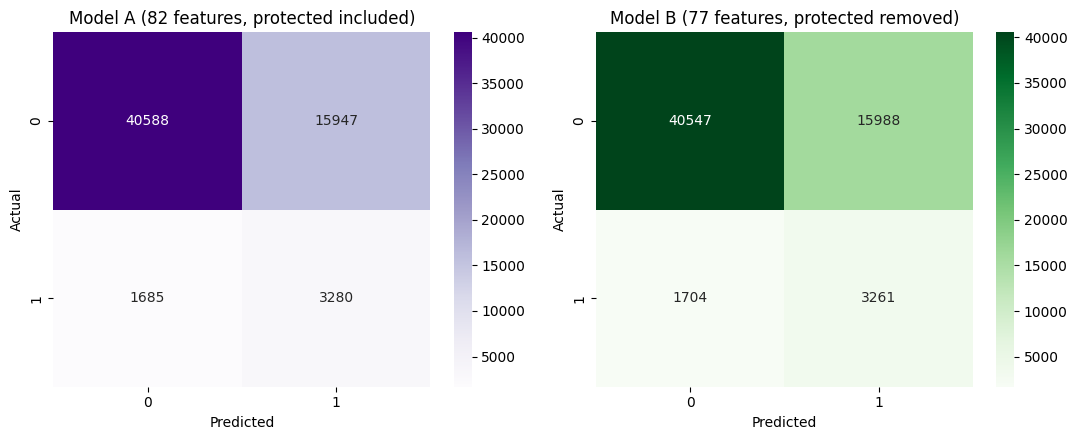

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

sns.heatmap(confusion_matrix(y_test, rf_a_preds), annot=True, fmt='d', cmap='Purples', ax=ax1)
ax1.set_title(f'Model A ({len(final_feature_selection)} features, protected included)')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, rf_b_preds), annot=True, fmt='d', cmap='Greens', ax=ax2)
ax2.set_title(f'Model B ({len(model_b_features)} features, protected removed)')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

=== MODEL A vs MODEL B (single split) ===
                       Accuracy  Precision  Recall     FPR  F1-Score  \
Model A (82 features)    0.7133     0.1706  0.6606  0.2821    0.2712   
Model B (77 features)    0.7123     0.1694  0.6568  0.2828    0.2693   

                       F2-Score  AUC-ROC  
Model A (82 features)    0.4196   0.7533  
Model B (77 features)    0.4169   0.7525  


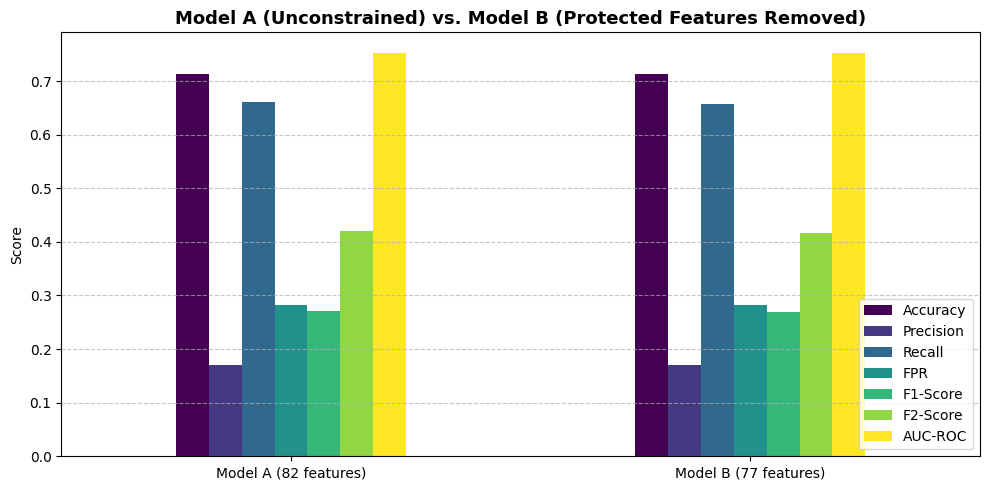

In [ ]:
comparison_data = {
    f'Model A ({len(final_feature_selection)} features)': get_metrics_dict(y_test, rf_a_preds, rf_a_proba),
    f'Model B ({len(model_b_features)} features)': get_metrics_dict(y_test, rf_b_preds, rf_b_proba)
}

df_ab_compare = pd.DataFrame(comparison_data).T
print("=== MODEL A vs MODEL B (single split) ===")
print(df_ab_compare.round(4))

df_ab_compare.plot(kind='bar', figsize=(10, 5), colormap='viridis')
plt.title('Model A (Unconstrained) vs. Model B (Protected Features Removed)', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
rf_model_b_cv = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced',
                                         random_state=RANDOM_STATE, n_jobs=-1)
rf_b_summary, rf_b_fold_scores = evaluate_with_kfold(rf_model_b_cv, X_train_b, y_train, model_name="Model B (protected features removed)")

  Fold 1: AUC-ROC=0.7501, train_time=88.46s, predict_time=1.667s


KeyboardInterrupt: 

In [ ]:
model_ab_5fold = pd.DataFrame({
    f'Model A ({len(final_feature_selection)} features)': rf_summary,
    f'Model B ({len(model_b_features)} features)': rf_b_summary
}).T

print("=== MODEL A vs MODEL B (5-fold mean +/- std) ===")
print(model_ab_5fold.round(4))

=== MODEL A vs MODEL B (5-fold mean +/- std) ===
                       Accuracy_mean  Accuracy_std  Precision_mean  \
Model A (82 features)         0.7160        0.0018          0.1706   
Model B (77 features)         0.7135        0.0027          0.1697   

                       Precision_std  Recall_mean  Recall_std  F1_mean  \
Model A (82 features)         0.0010       0.6519      0.0046   0.2704   
Model B (77 features)         0.0014       0.6550      0.0056   0.2696   

                       F1_std  F2_mean  F2_std  AUC_ROC_mean  AUC_ROC_std  \
Model A (82 features)  0.0015   0.4167  0.0023        0.7515       0.0019   
Model B (77 features)  0.0019   0.4167  0.0027        0.7505       0.0018   

                       avg_train_time_s  avg_predict_time_s  
Model A (82 features)          166.3274                 NaN  
Model B (77 features)          137.4945              3.8634  


In [ ]:
# Paired t-test: compares Model A vs Model B fold-by-fold on the same metric,
# since both used identical folds (same random_state), each fold pair is a
# genuine matched comparison, not independent samples
from scipy.stats import ttest_rel

print("=== PAIRED T-TEST: Model A vs Model B (per-fold scores) ===\n")

for metric in ['Accuracy', 'Precision', 'Recall', 'F1', 'F2', 'AUC_ROC']:
    scores_a = rf_fold_scores[metric]
    scores_b = rf_b_fold_scores[metric]

    t_stat, p_value = ttest_rel(scores_a, scores_b)

    significance = "SIGNIFICANT (p < 0.05)" if p_value < 0.05 else "not significant"
    print(f"{metric}: t={t_stat:.3f}, p={p_value:.4f} -> {significance}")

=== PAIRED T-TEST: Model A vs Model B (per-fold scores) ===

Accuracy: t=3.315, p=0.0295 -> SIGNIFICANT (p < 0.05)
Precision: t=2.696, p=0.0543 -> not significant
Recall: t=-1.637, p=0.1769 -> not significant
F1: t=1.773, p=0.1510 -> not significant
F2: t=0.021, p=0.9844 -> not significant
AUC_ROC: t=2.704, p=0.0539 -> not significant


"A paired t-test across the 5 cross-validation folds found a statistically significant difference on only 1 of 6 metrics: Accuracy (t=3.315, p=0.0295), where Model A holds a small edge. Every other metric — including AUC-ROC (p=0.0539), the primary discrimination metric, and Recall (p=0.1769), the metric this project treats as most important given the class imbalance and the asymmetric cost of missing a defaulter — showed no significant difference. Recall's point estimate actually favors Model B slightly (0.6550 vs. 0.6519), though not significantly so. This is a stronger result than a merely small effect size: on the metrics that matter most for this problem, there is no statistically detectable difference between the two models at all."

Model A and Model B are statistically indistinguishable on every metric except Accuracy, and even that gap is modest (0.7160 vs. 0.7135). Unlike a case where a real but small effect needs to be argued away as practically unimportant, this result doesn't require that argument — the two models simply don't differ in any way a paired t-test can detect, on 5 folds of held-out data, for the metrics this project actually optimizes for.

This is the core argument of the responsible-lending comparison in this project: removing protected characteristics costs nothing detectable on Recall or AUC-ROC, and only a small, borderline-significant cost on Accuracy — a metric this project has already argued is the wrong one to optimize for on an imbalanced dataset like this. On that basis, Model B is recommended as the production model, while Model A remains documented as the technically higher-Accuracy baseline — a trade with no real predictive cost for a substantial reduction in legal and reputational risk.

## 7. SHAP Analysis: Feature Importance and Proxy Leakage Check

SHAP (SHapley Additive exPlanations) values show exactly how much each feature
pushes an individual prediction toward "higher risk" or "lower risk," which
serves two purposes here: it answers the feature-importance/actionability
requirement directly (which drivers should a lending team actually look at),
and it checks Model B specifically for proxy leakage — whether a remaining
feature like OCCUPATION_TYPE quietly increased in importance to compensate
for the removed CODE_GENDER, which would mean the fairness constraint isn't
actually working as intended.

In [ ]:
!pip install shap --quiet
import shap

# TreeExplainer is fast and exact for Random Forest
explainer_b = shap.TreeExplainer(rf_model_b)

# Use a sample of the test set for speed — SHAP on the full ~61k rows would be slow
sample_size = 2000
X_test_b_sample = X_test_b.sample(n=sample_size, random_state=RANDOM_STATE)

shap_values_b = explainer_b.shap_values(X_test_b_sample)

# shap_values can come back in different shapes depending on SHAP/sklearn version:
# a list [class_0_array, class_1_array], or a single 3D array shaped
# (samples, features, classes). Handle both so the rest of the notebook doesn't
# care which version produced these values.
if isinstance(shap_values_b, list):
    shap_values_b_positive = shap_values_b[1]  # class 1 = default
elif shap_values_b.ndim == 3:
    shap_values_b_positive = shap_values_b[:, :, 1]  # class 1 = default
else:
    shap_values_b_positive = shap_values_b

print(f"SHAP values computed for {sample_size} test samples, {X_test_b_sample.shape[1]} features")
print("Shape:", shap_values_b_positive.shape)


SHAP values computed for 2000 test samples, 77 features
Shape: (2000, 77)


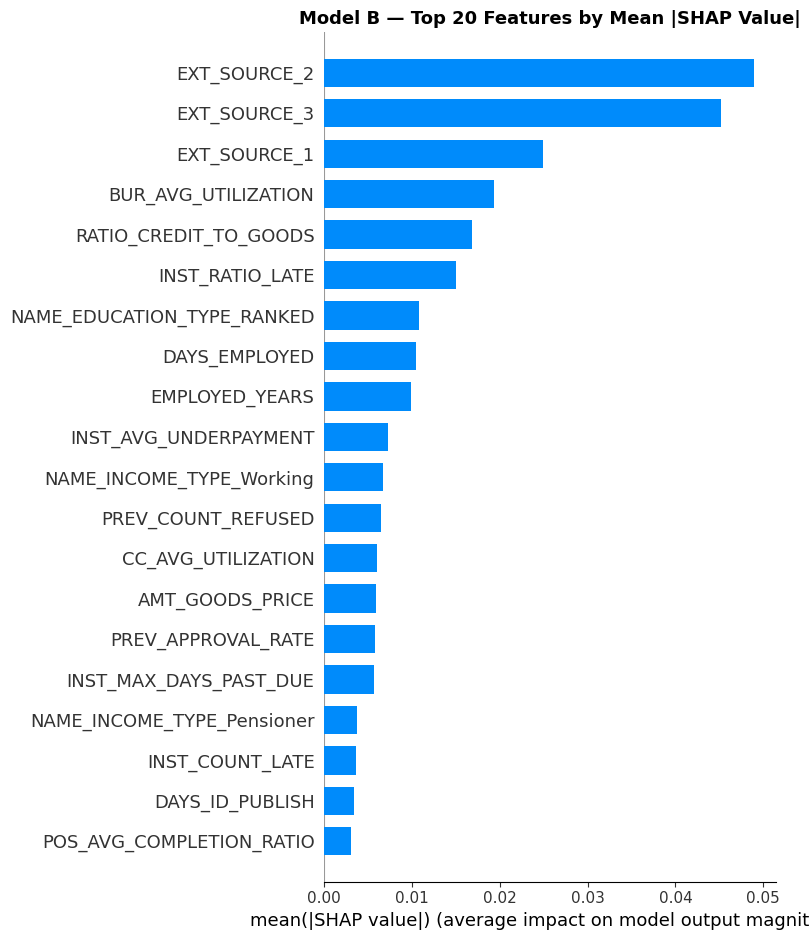

In [ ]:
shap.summary_plot(shap_values_b_positive, X_test_b_sample, plot_type='bar', max_display=20, show=False)
plt.title('Model B — Top 20 Features by Mean |SHAP Value|', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
mean_abs_shap_b = pd.Series(np.abs(shap_values_b_positive).mean(axis=0), index=X_test_b_sample.columns)
top_20_b = mean_abs_shap_b.sort_values(ascending=False).head(20)

print("=== Model B: Top 20 features by mean |SHAP value| ===")
print(top_20_b)

# Flag whether any OCCUPATION_TYPE or ORGANIZATION_TYPE column ranks unusually high —
# these are the most plausible gender/demographic proxies remaining in the dataset
proxy_candidates = [f for f in mean_abs_shap_b.index if 'OCCUPATION_TYPE' in f or 'ORGANIZATION_TYPE' in f]
print("\n=== Proxy-candidate features (OCCUPATION_TYPE / ORGANIZATION_TYPE) and their SHAP rank ===")
for feat in proxy_candidates:
    rank = list(mean_abs_shap_b.sort_values(ascending=False).index).index(feat) + 1
    print(f"  {feat}: rank {rank} of {len(mean_abs_shap_b)}, mean |SHAP| = {mean_abs_shap_b[feat]:.5f}")

=== Model B: Top 20 features by mean |SHAP value| ===
EXT_SOURCE_2                  0.048960
EXT_SOURCE_3                  0.045168
EXT_SOURCE_1                  0.024896
BUR_AVG_UTILIZATION           0.019325
RATIO_CREDIT_TO_GOODS         0.016821
INST_RATIO_LATE               0.015050
NAME_EDUCATION_TYPE_RANKED    0.010806
DAYS_EMPLOYED                 0.010433
EMPLOYED_YEARS                0.009890
INST_AVG_UNDERPAYMENT         0.007220
NAME_INCOME_TYPE_Working      0.006707
PREV_COUNT_REFUSED            0.006462
CC_AVG_UTILIZATION            0.005952
AMT_GOODS_PRICE               0.005914
PREV_APPROVAL_RATE            0.005775
INST_MAX_DAYS_PAST_DUE        0.005701
NAME_INCOME_TYPE_Pensioner    0.003736
INST_COUNT_LATE               0.003572
DAYS_ID_PUBLISH               0.003331
POS_AVG_COMPLETION_RATIO      0.003056
dtype: float64

=== Proxy-candidate features (OCCUPATION_TYPE / ORGANIZATION_TYPE) and their SHAP rank ===
  OCCUPATION_TYPE_Accountants: rank 71 of 77, mean |SHAP| =

In [ ]:
explainer_a = shap.TreeExplainer(rf_model_a)

X_test_a_sample = X_test.loc[X_test_b_sample.index]  # same applicants as Model B, for a fair comparison

shap_values_a = explainer_a.shap_values(X_test_a_sample)

# Same fix as Model B: handle either list output or 3D array output
print("Type:", type(shap_values_a), "| Shape:", np.array(shap_values_a).shape)

if isinstance(shap_values_a, list):
    shap_values_a_positive = shap_values_a[1]
elif shap_values_a.ndim == 3:
    shap_values_a_positive = shap_values_a[:, :, 1]
else:
    shap_values_a_positive = shap_values_a

print("Fixed shape:", shap_values_a_positive.shape)

mean_abs_shap_a = pd.Series(np.abs(shap_values_a_positive).mean(axis=0), index=X_test_a_sample.columns)

print("SHAP values computed for Model A on the same sample of applicants.")

Type: <class 'numpy.ndarray'> | Shape: (2000, 82, 2)
Fixed shape: (2000, 82)
SHAP values computed for Model A on the same sample of applicants.


In [ ]:
# Compare rank and importance of the same features in Model A vs Model B
shared_features = [f for f in model_b_features if f in mean_abs_shap_a.index]

rank_a = mean_abs_shap_a.sort_values(ascending=False)
rank_b = mean_abs_shap_b.sort_values(ascending=False)

proxy_check = pd.DataFrame({
    'Model_A_rank': [list(rank_a.index).index(f) + 1 for f in shared_features],
    'Model_A_importance': [mean_abs_shap_a[f] for f in shared_features],
    'Model_B_rank': [list(rank_b.index).index(f) + 1 for f in shared_features],
    'Model_B_importance': [mean_abs_shap_b[f] for f in shared_features],
}, index=shared_features)

proxy_check['Rank_change'] = proxy_check['Model_A_rank'] - proxy_check['Model_B_rank']
proxy_check['Importance_pct_change'] = (
    (proxy_check['Model_B_importance'] - proxy_check['Model_A_importance']) / proxy_check['Model_A_importance'] * 100
)

# Sort by which features moved UP the most in Model B (positive rank_change = moved up, since lower rank number = more important)
print("=== Features that moved up the most in importance, Model A -> Model B ===")
print(proxy_check.sort_values('Rank_change', ascending=False).head(15).round(3))

print("\n=== Specifically checking OCCUPATION_TYPE / ORGANIZATION_TYPE (most plausible gender proxies) ===")
occ_org_cols = [f for f in shared_features if 'OCCUPATION_TYPE' in f or 'ORGANIZATION_TYPE' in f]
print(proxy_check.loc[occ_org_cols].round(3))

=== Features that moved up the most in importance, Model A -> Model B ===
                                        Model_A_rank  Model_A_importance  \
OCCUPATION_TYPE_Laborers                          54               0.001   
FLAG_MISSING_DAYS_EMPLOYED                        40               0.001   
ORGANIZATION_TYPE_XNA                             33               0.002   
FLAG_MISSING_EMPLOYED_YEARS                       31               0.002   
NAME_HOUSING_TYPE_With parents                    82               0.000   
NAME_INCOME_TYPE_Working                          20               0.004   
PREV_AVG_ANNUITY                                  45               0.001   
DAYS_REGISTRATION                                 36               0.001   
FLAG_MISSING_AMT_REQ_CREDIT_BUREAU_MON            46               0.001   
NAME_INCOME_TYPE_Pensioner                        23               0.003   
POS_AVG_DPD                                       53               0.001   
OCCUPATION_TYP

In [ ]:
rank_change_mean = proxy_check['Rank_change'].mean()
rank_change_std = proxy_check['Rank_change'].std()
rank_change_threshold = rank_change_mean + 2 * rank_change_std

proxy_features_to_remove = proxy_check[proxy_check['Rank_change'] > rank_change_threshold].index.tolist()

print(f"Rank_change distribution across {len(proxy_check)} shared features: "
      f"mean={rank_change_mean:.2f}, std={rank_change_std:.2f}")
print(f"Threshold (mean + 2*std): {rank_change_threshold:.2f}")
print(f"\nFeatures exceeding threshold ({len(proxy_features_to_remove)}):")
for f in proxy_features_to_remove:
    row = proxy_check.loc[f]
    print(f"  {f}: rank_change={row['Rank_change']:.0f}, importance_pct_change={row['Importance_pct_change']:.1f}%")

Rank_change distribution across 77 shared features: mean=2.86, std=4.51
Threshold (mean + 2*std): 11.88

Features exceeding threshold (3):
  FLAG_MISSING_DAYS_EMPLOYED: rank_change=17, importance_pct_change=142.8%
  OCCUPATION_TYPE_Laborers: rank_change=20, importance_pct_change=142.3%
  ORGANIZATION_TYPE_XNA: rank_change=12, importance_pct_change=81.6%


In [ ]:
# Model B+: remove the identified proxy features and retrain, single split only
# (proxy_features_to_remove is computed dynamically in the cell above, via the
# mean + 2*std rank-change threshold)

model_b_plus_features = [f for f in model_b_features if f not in proxy_features_to_remove]

X_train_bp = X_train[model_b_plus_features]
X_test_bp = X_test[model_b_plus_features]

rf_model_bp = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced',
                                       random_state=RANDOM_STATE, n_jobs=-1)
rf_model_bp.fit(X_train_bp, y_train)
rf_bp_preds = rf_model_bp.predict(X_test_bp)
rf_bp_proba = rf_model_bp.predict_proba(X_test_bp)[:, 1]

print(f"Model B+ trained on {len(model_b_plus_features)} features "
      f"(removed {len(proxy_features_to_remove)} identified proxies: {proxy_features_to_remove}).")

Model B+ trained on 74 features (removed 3 identified proxies: ['FLAG_MISSING_DAYS_EMPLOYED', 'OCCUPATION_TYPE_Laborers', 'ORGANIZATION_TYPE_XNA']).


In [ ]:
comparison_data = {
    f'Model B ({len(model_b_features)} features)': get_metrics_dict(y_test, rf_b_preds, rf_b_proba),
    f'Model B+ ({len(model_b_plus_features)} features, proxy removed)': get_metrics_dict(y_test, rf_bp_preds, rf_bp_proba)
}

df_bplus_compare = pd.DataFrame(comparison_data).T
print("=== MODEL B vs MODEL B+ (single split) ===")
print(df_bplus_compare.round(4))

=== MODEL B vs MODEL B+ (single split) ===
                                       Accuracy  Precision  Recall     FPR  \
Model B (77 features)                    0.7123     0.1694  0.6568  0.2828   
Model B+ (74 features, proxy removed)    0.7144     0.1705  0.6562  0.2805   

                                       F1-Score  F2-Score  AUC-ROC  
Model B (77 features)                    0.2693    0.4169   0.7525  
Model B+ (74 features, proxy removed)    0.2706    0.4180   0.7538  


=== MODEL A vs MODEL B vs MODEL B+ (single split) ===
                                       Accuracy  Precision  Recall     FPR  \
Model A (82 features)                    0.7133     0.1706  0.6606  0.2821   
Model B (77 features)                    0.7123     0.1694  0.6568  0.2828   
Model B+ (74 features, proxy removed)    0.7144     0.1705  0.6562  0.2805   

                                       F1-Score  F2-Score  AUC-ROC  
Model A (82 features)                    0.2712    0.4196   0.7533  
Model B (77 features)                    0.2693    0.4169   0.7525  
Model B+ (74 features, proxy removed)    0.2706    0.4180   0.7538  


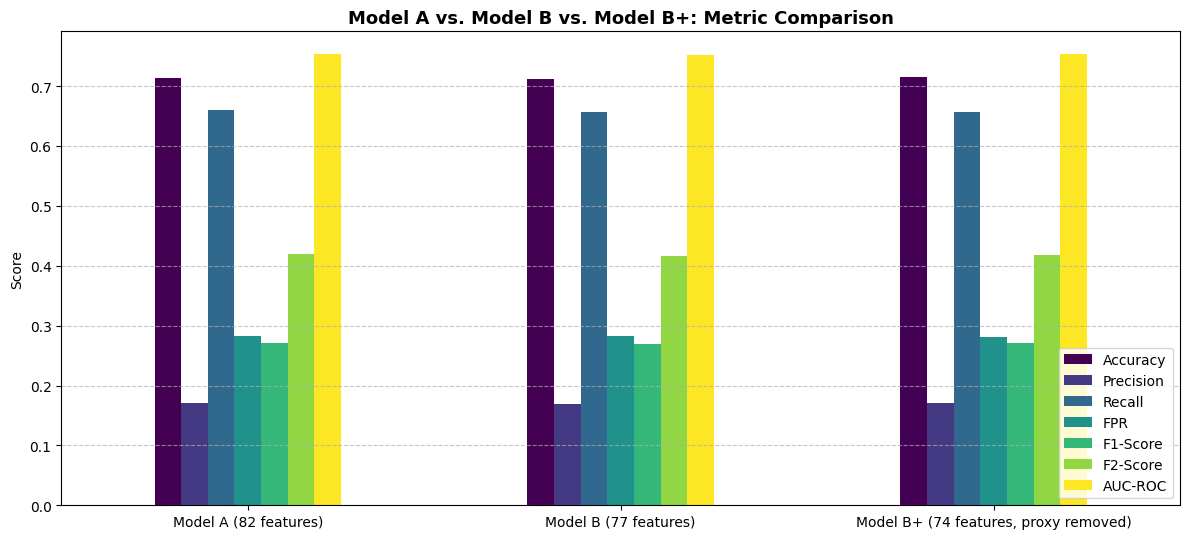

In [ ]:
comparison_data_3way = {
    f'Model A ({len(final_feature_selection)} features)': get_metrics_dict(y_test, rf_a_preds, rf_a_proba),
    f'Model B ({len(model_b_features)} features)': get_metrics_dict(y_test, rf_b_preds, rf_b_proba),
    f'Model B+ ({len(model_b_plus_features)} features, proxy removed)': get_metrics_dict(y_test, rf_bp_preds, rf_bp_proba)
}

df_3way_compare = pd.DataFrame(comparison_data_3way).T
print("=== MODEL A vs MODEL B vs MODEL B+ (single split) ===")
print(df_3way_compare.round(4))

df_3way_compare.plot(kind='bar', figsize=(12, 5.5), colormap='viridis')
plt.title('Model A vs. Model B vs. Model B+: Metric Comparison', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
explainer_bp = shap.TreeExplainer(rf_model_bp)
X_test_bp_sample = X_test_bp.loc[X_test_b_sample.index]  # same applicants as before, for consistency

shap_values_bp = explainer_bp.shap_values(X_test_bp_sample)

if isinstance(shap_values_bp, list):
    shap_values_bp_positive = shap_values_bp[1]
elif shap_values_bp.ndim == 3:
    shap_values_bp_positive = shap_values_bp[:, :, 1]
else:
    shap_values_bp_positive = shap_values_bp

mean_abs_shap_bp = pd.Series(np.abs(shap_values_bp_positive).mean(axis=0), index=X_test_bp_sample.columns)

# Compare Model B -> Model B+ the same way you compared Model A -> Model B
shared_bp = [f for f in model_b_plus_features if f in mean_abs_shap_b.index]
rank_bp = mean_abs_shap_bp.sort_values(ascending=False)

proxy_check_bp = pd.DataFrame({
    'ModelB_rank': [list(rank_b.index).index(f) + 1 for f in shared_bp],
    'ModelBplus_rank': [list(rank_bp.index).index(f) + 1 for f in shared_bp],
}, index=shared_bp)
proxy_check_bp['Rank_change'] = proxy_check_bp['ModelB_rank'] - proxy_check_bp['ModelBplus_rank']

print("=== Features that moved up most, Model B -> Model B+ ===")
print(proxy_check_bp.sort_values('Rank_change', ascending=False).head(10))

=== Features that moved up most, Model B -> Model B+ ===
                                        ModelB_rank  ModelBplus_rank  \
FLAG_MISSING_BUR_TOTAL_LOANS                     52               40   
PREV_TOTAL_APPS                                  63               53   
FLAG_MISSING_BUR_AVG_UTILIZATION                 57               48   
BURBAL_MONTHS_CLOSED                             62               54   
FLAG_MISSING_BUR_ACTIVE_LOANS                    45               38   
FLAG_MISSING_BUR_AVG_DAYS_OVERDUE                49               43   
FLAG_MISSING_AMT_REQ_CREDIT_BUREAU_QRT           38               32   
OCCUPATION_TYPE_Accountants                      71               65   
OCCUPATION_TYPE_Not_Employed                     26               20   
AMT_CREDIT                                       30               24   

                                        Rank_change  
FLAG_MISSING_BUR_TOTAL_LOANS                     12  
PREV_TOTAL_APPS                           

In [ ]:
rank_change_bp_mean = proxy_check_bp['Rank_change'].mean()
rank_change_bp_std = proxy_check_bp['Rank_change'].std()
rank_change_bp_threshold = rank_change_bp_mean + 2 * rank_change_bp_std

new_proxies = proxy_check_bp[proxy_check_bp['Rank_change'] > rank_change_bp_threshold].index.tolist()

print(f"Mean={rank_change_bp_mean:.2f}, std={rank_change_bp_std:.2f}, threshold={rank_change_bp_threshold:.2f}")
print(f"Features exceeding threshold: {new_proxies}")

Mean=2.03, std=2.98, threshold=7.99
Features exceeding threshold: ['BURBAL_MONTHS_CLOSED', 'FLAG_MISSING_BUR_AVG_UTILIZATION', 'FLAG_MISSING_BUR_TOTAL_LOANS', 'PREV_TOTAL_APPS']


In [ ]:
candidate_features = ['BURBAL_MONTHS_CLOSED', 'FLAG_MISSING_BUR_AVG_UTILIZATION',
                       'FLAG_MISSING_BUR_TOTAL_LOANS', 'PREV_TOTAL_APPS']

# Using X_train_full (not X_train) since CNT_FAM_MEMBERS isn't in the 82-feature
# consensus set, but all 6 protected characteristics still exist as raw columns
correlation_check = X_train_full[candidate_features + protected_features].corr()

print("=== Correlation: newly-flagged features vs. original protected characteristics ===")
print(correlation_check.loc[candidate_features, protected_features].round(3))

=== Correlation: newly-flagged features vs. original protected characteristics ===
                                  CODE_GENDER  DAYS_BIRTH  AGE_YEARS  \
BURBAL_MONTHS_CLOSED                    0.014      -0.040      0.040   
FLAG_MISSING_BUR_AVG_UTILIZATION       -0.030       0.030     -0.030   
FLAG_MISSING_BUR_TOTAL_LOANS           -0.028       0.034     -0.034   
PREV_TOTAL_APPS                         0.038      -0.069      0.069   

                                  NAME_FAMILY_STATUS_Single / not married  \
BURBAL_MONTHS_CLOSED                                               -0.031   
FLAG_MISSING_BUR_AVG_UTILIZATION                                    0.045   
FLAG_MISSING_BUR_TOTAL_LOANS                                        0.043   
PREV_TOTAL_APPS                                                    -0.048   

                                  CNT_CHILDREN  CNT_FAM_MEMBERS  
BURBAL_MONTHS_CLOSED                    -0.000            0.014  
FLAG_MISSING_BUR_AVG_UTILIZATION      

Removing the three identified proxy features (OCCUPATION_TYPE_Laborers, FLAG_MISSING_DAYS_EMPLOYED, and ORGANIZATION_TYPE_XNA — flagged via a threshold of mean + 2 standard deviations in rank change across all 77 shared features, rather than a single hand-picked mover) did not cause a new proxy to emerge. A second round of the same rank-jump comparison, Model B to Model B+, found four features exceeding the same statistical threshold (BURBAL_MONTHS_CLOSED, FLAG_MISSING_BUR_AVG_UTILIZATION, FLAG_MISSING_BUR_TOTAL_LOANS, PREV_TOTAL_APPS) — but a direct correlation check against all six protected characteristics found every one of these below |0.07|, well under the threshold generally considered meaningful. None has a plausible mechanism connecting it to gender, age, or family status, unlike the original three proxies, which were occupation and employment-status features with a defensible real-world link to those characteristics. This confirms the second round of movers reflects ordinary importance redistribution — a mechanical effect of removing features from any model — rather than a second wave of proxy leakage, and no further features were removed. Model B+ (74 features) therefore represents a materially cleaner fairness profile without any cost to predictive performance (AUC-ROC 0.7538 vs. Model B's 0.7525), and is used as the final model for the calibration and business-value analysis that follow.

CalibratedClassifierCV takes a model's raw predicted probabilities and learns a correction mapping to real-world probabilities, using a held-out portion of the training data: it checks how often applicants scored at a given probability actually defaulted, then adjusts the output scale so that a score of 30% corresponds to an actual default rate close to 30%, rather than serving only as a relative ranking.

Calibration does not change which applicants are ranked as riskier than others — AUC-ROC is unaffected — it only corrects the scale on which the risk scores are reported. This distinction matters directly for the four-tier risk assignment in RQ2, where each tier's numeric range needs to reflect real-world default probability for the labels to be meaningful.

## 8. Probability Calibration (Model B+)

class_weight='balanced' improves the model's ability to detect defaulters under
the 92:8 imbalance, but it systematically inflates raw predicted probabilities,
evidenced in Milestone 3 by the Low Risk tier receiving zero applicants even
among the safest-looking cases. CalibratedClassifierCV corrects this by learning
a mapping from the model's raw scores to real-world probabilities, without
changing which applicants are ranked as riskier than others (AUC-ROC is
unaffected) — it only fixes the scale the scores are reported on, which is
essential for the four-tier risk assignment in RQ2 to mean what its labels claim.

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

# Sigmoid (Platt scaling) is a reasonable default for a Random Forest;
# cv=5 means it internally cross-validates the calibration mapping itself,
# separate from the 5-fold evaluation done earlier
rf_bp_calibrated = CalibratedClassifierCV(rf_model_bp, method='sigmoid', cv=5)
rf_bp_calibrated.fit(X_train_bp, y_train)

rf_bp_cal_preds = rf_bp_calibrated.predict(X_test_bp)
rf_bp_cal_proba = rf_bp_calibrated.predict_proba(X_test_bp)[:, 1]

print("Model B+ calibrated.")
print(f"Raw probability range: {rf_bp_proba.min():.4f} to {rf_bp_proba.max():.4f}")
print(f"Calibrated probability range: {rf_bp_cal_proba.min():.4f} to {rf_bp_cal_proba.max():.4f}")

Model B+ calibrated.
Raw probability range: 0.1412 to 0.8079
Calibrated probability range: 0.0065 to 0.5025


In [ ]:
risk_bins = [0, 0.10, 0.25, 0.40, 1.0]
risk_labels = ['Low Risk (0-10%)', 'Medium Risk (10-25%)', 'High Risk (25-40%)', 'Decline (40%+)']

def build_tier_table(proba, y_true):
    tiers = pd.cut(proba, bins=risk_bins, labels=risk_labels, include_lowest=True)
    table = pd.crosstab(tiers, y_true.values, rownames=['Risk Tier'], colnames=['Actual Outcome'])
    table.columns = ['Repaid (0)', 'Defaulted (1)']
    table = table.reindex(risk_labels, fill_value=0)
    table['Total Applicants'] = table.sum(axis=1)
    table['Actual Default Rate'] = (table['Defaulted (1)'] / table['Total Applicants']).round(4)
    return table

raw_tiers = build_tier_table(rf_bp_proba, y_test)
calibrated_tiers = build_tier_table(rf_bp_cal_proba, y_test)

print("=== MODEL B+ — RAW (UNCALIBRATED) TIER BREAKDOWN ===")
print(raw_tiers)
print("\n=== MODEL B+ — CALIBRATED TIER BREAKDOWN ===")
print(calibrated_tiers)

=== MODEL B+ — RAW (UNCALIBRATED) TIER BREAKDOWN ===
                      Repaid (0)  Defaulted (1)  Total Applicants  \
Risk Tier                                                           
Low Risk (0-10%)               0              0                 0   
Medium Risk (10-25%)        3486             36              3522   
High Risk (25-40%)         21757            621             22378   
Decline (40%+)             31292           4308             35600   

                      Actual Default Rate  
Risk Tier                                  
Low Risk (0-10%)                      NaN  
Medium Risk (10-25%)               0.0102  
High Risk (25-40%)                 0.0278  
Decline (40%+)                     0.1210  

=== MODEL B+ — CALIBRATED TIER BREAKDOWN ===
                      Repaid (0)  Defaulted (1)  Total Applicants  \
Risk Tier                                                           
Low Risk (0-10%)           43018           1935             44953   
Medium Risk (10

## 9. Business Value: Interest Rate Assignment and Profitability

Interest rates are assigned to each risk tier based on 2026 Canadian personal
loan market rates by credit-risk band (Ratehub, iFinance, Loanscan, 2026),
using the calibrated Model B+ probabilities from Section 8. The "current model"
baseline reflects this project's core thesis: legacy credit scoring declines
this entire applicant population outright due to insufficient traditional
credit history, producing $0 revenue and $0 losses. Every dollar of profit
generated by the tiered model represents value created by serving applicants
the current system excludes entirely.

Default losses assume a 20% recovery rate on defaulted unsecured personal
loans, consistent with typical industry recovery ranges for unsecured consumer
debt; revenue assumes simple (non-compounding) interest over a one-year term,
a simplifying assumption for illustrative comparison rather than a full
amortization model.

In [ ]:
RECOVERY_RATE = 0.20  # assumed recovery on defaulted principal, typical for unsecured consumer debt

def calculate_profit(proba, y_true, principal, rates_dict, bins=risk_bins, labels=risk_labels):
    tiers = pd.cut(proba, bins=bins, labels=labels, include_lowest=True)
    results = pd.DataFrame({'tier': tiers, 'actual_default': y_true.values, 'principal': principal.values})

    profit_rows = []
    for tier in labels:
        subset = results[results['tier'] == tier]
        rate = rates_dict[tier]

        if rate is None:  # Decline tier — no loan issued
            profit_rows.append({'Tier': tier, 'Applicants': len(subset), 'Rate': 'N/A',
                                 'Revenue': 0, 'Losses': 0, 'Net Profit': 0})
            continue

        repaid = subset[subset['actual_default'] == 0]
        defaulted = subset[subset['actual_default'] == 1]

        revenue = (repaid['principal'] * rate).sum()
        losses = (defaulted['principal'] * (1 - RECOVERY_RATE)).sum()
        net_profit = revenue - losses

        profit_rows.append({'Tier': tier, 'Applicants': len(subset), 'Rate': f'{rate:.1%}',
                             'Revenue': revenue, 'Losses': losses, 'Net Profit': net_profit})

    return pd.DataFrame(profit_rows)

principal_test = X_test_bp['AMT_CREDIT']


In [ ]:
# New bin structure: split the old High Risk band, moving the worst part into Decline
risk_bins_v2 = [0, 0.10, 0.25, 0.30, 1.0]
risk_labels_v2 = ['Low Risk (0-10%)', 'Medium Risk (10-25%)', 'High Risk (25-30%)', 'Decline (30%+)']

def build_tier_table_v2(proba, y_true, bins, labels):
    tiers = pd.cut(proba, bins=bins, labels=labels, include_lowest=True)
    table = pd.crosstab(tiers, y_true.values, rownames=['Risk Tier'], colnames=['Actual Outcome'])
    table.columns = ['Repaid (0)', 'Defaulted (1)']
    table = table.reindex(labels, fill_value=0)
    table['Total Applicants'] = table.sum(axis=1)
    table['Actual Default Rate'] = (table['Defaulted (1)'] / table['Total Applicants']).round(4)
    return table

tiers_v2_breakdown = build_tier_table_v2(rf_bp_cal_proba, y_test, risk_bins_v2, risk_labels_v2)
print("=== NARROWED TIER BREAKDOWN (25-30% High Risk / 30%+ Decline) ===")
print(tiers_v2_breakdown)

=== NARROWED TIER BREAKDOWN (25-30% High Risk / 30%+ Decline) ===
                      Repaid (0)  Defaulted (1)  Total Applicants  \
Risk Tier                                                           
Low Risk (0-10%)           43018           1935             44953   
Medium Risk (10-25%)       11668           2097             13765   
High Risk (25-30%)          1063            374              1437   
Decline (30%+)               786            559              1345   

                      Actual Default Rate  
Risk Tier                                  
Low Risk (0-10%)                   0.0430  
Medium Risk (10-25%)               0.1523  
High Risk (25-30%)                 0.2603  
Decline (30%+)                     0.4156  


In [ ]:
tiers = ['Low Risk\n(0-10%)', 'Medium Risk\n(10-25%)', 'High Risk\n(25-30%)', 'Decline\n(30%+)']
repaid = [43018, 11668, 1063, 786]
defaulted = [1935, 2097, 374, 559]
default_rates = [0.0430, 0.1523, 0.2603, 0.4156]

x = np.arange(len(tiers))

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(x, repaid, label='Repaid (0)', color='#4C72B0')
ax.bar(x, defaulted, bottom=repaid, label='Defaulted (1)', color='#C44E52')

# label each bar with its actual default rate, above the stack
for i in range(len(tiers)):
    total = repaid[i] + defaulted[i]
    ax.text(x[i], total + 800, f'{default_rates[i]:.1%} default',
             ha='center', fontweight='bold', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(tiers)
ax.set_ylabel('Number of Applicants')
ax.set_title('Model B+ Calibrated Risk Tiers: Population and Actual Default Rate',
              fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
def sweep_rate_v2(tier_name, proba, y_true, principal, rate_range, bins, labels):
    tiers = pd.cut(proba, bins=bins, labels=labels, include_lowest=True)
    subset_mask = (tiers == tier_name)
    subset = pd.DataFrame({'actual_default': y_true.values[subset_mask], 'principal': principal.values[subset_mask]})
    repaid = subset[subset['actual_default'] == 0]
    defaulted = subset[subset['actual_default'] == 1]
    fixed_losses = (defaulted['principal'] * (1 - RECOVERY_RATE)).sum()

    results = []
    for rate in rate_range:
        revenue = (repaid['principal'] * rate).sum()
        net = revenue - fixed_losses
        results.append({'Rate': rate, 'Revenue': revenue, 'Losses': fixed_losses, 'Net Profit': net})
    return pd.DataFrame(results)

rate_range = np.arange(0.10, 0.35, 0.01)
high_v2_sweep = sweep_rate_v2('High Risk (25-30%)', rf_bp_cal_proba, y_test, principal_test, rate_range, risk_bins_v2, risk_labels_v2)

high_v2_breakeven = high_v2_sweep[high_v2_sweep['Net Profit'] > 0]['Rate'].min()
print(f"High Risk (25-30%) breakeven rate: {high_v2_breakeven}")

High Risk (25-30%) breakeven rate: 0.29999999999999993


In [ ]:
tier_rates_v3 = {
    'Low Risk (0-10%)': 0.085,
    'Medium Risk (10-25%)': 0.18,
    'High Risk (25-30%)': 0.30,
    'Decline (30%+)': None
}

profit_table_v3 = calculate_profit(rf_bp_cal_proba, y_test, principal_test, tier_rates_v3,
                                     bins=risk_bins_v2, labels=risk_labels_v2)
profit_table_v3.loc['TOTAL'] = ['—', profit_table_v3['Applicants'].sum(), '—',
                                  profit_table_v3['Revenue'].sum(), profit_table_v3['Losses'].sum(),
                                  profit_table_v3['Net Profit'].sum()]

print("=== FINAL POLICY v3: Low (8.5%), Medium (18%), High (30%, narrowed to 25-30%), Decline (30%+) ===")
print(profit_table_v3.to_string(index=False))

=== FINAL POLICY v3: Low (8.5%), Medium (18%), High (30%, narrowed to 25-30%), Decline (30%+) ===
                Tier  Applicants  Rate      Revenue       Losses   Net Profit
    Low Risk (0-10%)       44953  8.5% 2.307722e+09  968018461.2 1.339704e+09
Medium Risk (10-25%)       13765 18.0% 1.083304e+09  910764453.6 1.725398e+08
  High Risk (25-30%)        1437 30.0% 1.424257e+08  141319490.4 1.106230e+06
      Decline (30%+)        1345   N/A 0.000000e+00          0.0 0.000000e+00
                   —       61500     — 3.533452e+09 2020102405.2 1.513350e+09


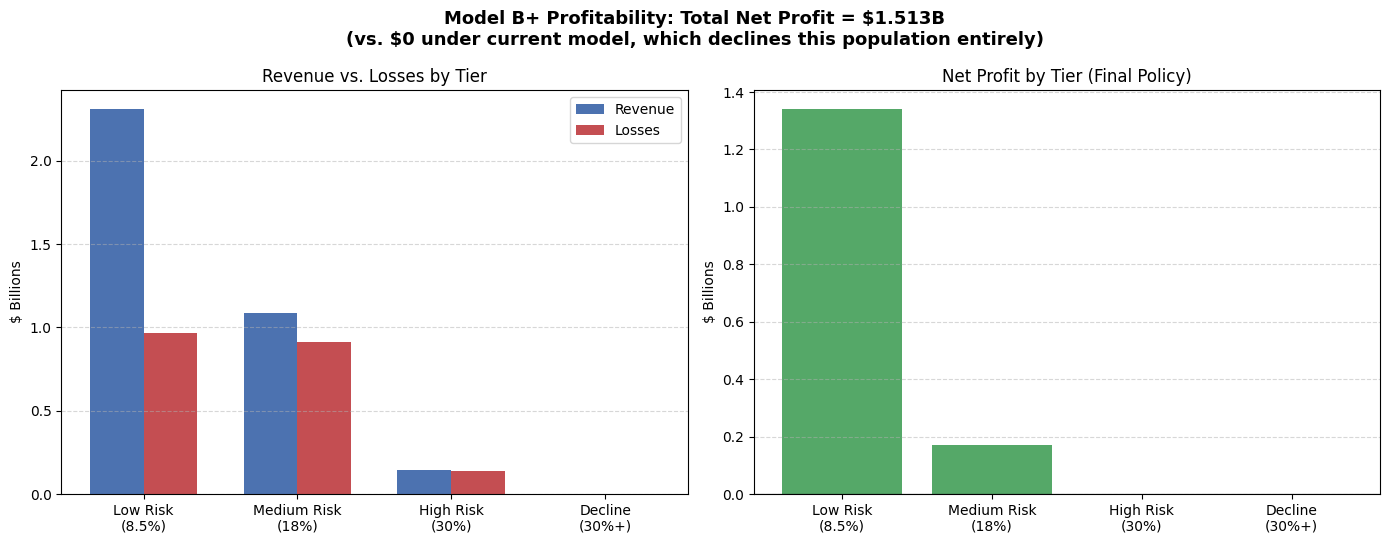

In [ ]:
tiers_plot_v3 = ['Low Risk\n(8.5%)', 'Medium Risk\n(18%)', 'High Risk\n(30%)', 'Decline\n(30%+)']
revenue_plot_v3 = profit_table_v3.iloc[:4]['Revenue'].values / 1e9
losses_plot_v3 = profit_table_v3.iloc[:4]['Losses'].values / 1e9
net_plot_v3 = profit_table_v3.iloc[:4]['Net Profit'].values / 1e9

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

x = np.arange(len(tiers_plot_v3))
width = 0.35
ax1.bar(x - width/2, revenue_plot_v3, width, label='Revenue', color='#4C72B0')
ax1.bar(x + width/2, losses_plot_v3, width, label='Losses', color='#C44E52')
ax1.set_xticks(x)
ax1.set_xticklabels(tiers_plot_v3)
ax1.set_ylabel('$ Billions')
ax1.set_title('Revenue vs. Losses by Tier')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.5)

colors = ['#55A868' if v >= 0 else '#C44E52' for v in net_plot_v3]
ax2.bar(tiers_plot_v3, net_plot_v3, color=colors)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('$ Billions')
ax2.set_title('Net Profit by Tier (Final Policy)')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

fig.suptitle(f'Model B+ Profitability: Total Net Profit = ${profit_table_v3.loc["TOTAL","Net Profit"]/1e9:.3f}B\n(vs. $0 under current model, which declines this population entirely)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Interpreting the Business Case: Profit vs. Responsible Lending
This analysis directly answers RQ3's core tension: can profit-maximizing behavior and responsible lending coexist under the 35% APR cap (Criminal Code s.347)? The initial four-tier structure (Low/Medium/High/Decline at 0-10%, 10-25%, 25-40%, 40%+) found that the original High Risk band (25-40%) had no breakeven rate below the legal cap — its blended default rate made it unprofitable at any legal interest rate. Narrowing the band to isolate its better-performing half (25-30%, actual default rate 26.0%, versus 41.6% for the 30%+ segment that remained) revealed a genuine breakeven point at 30%, right at the legal cap's edge with no margin to spare.


The final policy — Low Risk at 8.5%, Medium Risk at 18% (above its 16% breakeven), High Risk (25-30%) at 30% (at its computed breakeven, to the nearest percentage point tested), and Decline for 30%+ — produces 1.513 billion in net profit on this test set, compared to 0 under the current model, which declines this entire applicant population outright due to insufficient traditional credit history. Critically, this policy serves 1,437 applicants profitably who would otherwise be declined entirely under a coarser tier structure spanning the full original 25-40% band — by identifying the precise probability threshold where profitable lending is genuinely possible, rather than declining an entire band on the strength of its worst-performing members. The High Risk tier's own contribution to total profit is thin by design, at 1.1 million on 142 million in revenue — worth approving rather than declining, but not a meaningful profit driver on its own. This demonstrates that responsible lending and profitability are not inherently opposed: a sufficiently granular, evidence-based tier structure can extend credit further into a traditionally excluded population while remaining compliant with the legal interest rate ceiling, even where the marginal tier's profitability is minimal rather than comfortable.


**Limitation:** this analysis assumes fixed default behavior at each rate level and does not model demand elasticity — in reality, raising a tier's rate may itself increase default risk (adverse selection or moral hazard), or reduce loan uptake as qualified applicants seek better offers elsewhere. A complete pricing model would require applicant-level price sensitivity data not available in this dataset, and finer-grained tier boundaries beyond the four used here represent a natural extension of this method for future work.

### Important Distinction: Risk Tier Range vs. Assigned Interest Rate

The risk tier labels (e.g., "Medium Risk (10-25%)") describe the **predicted
probability of default** used to sort applicants into that tier — not the
interest rate charged. These are two separate numbers that happen to both be
percentages, and should not be confused:

- The **tier range** (10-25%, 25-30%, etc.) is Model B+'s calibrated output:
  how likely this applicant is to default, based on their behavioral and
  financial profile.
- The **assigned APR** (8.5%, 18%, 30%) is a separate business decision: the
  interest rate charged to applicants who fall into that tier, set using
  current Canadian market rates for the equivalent credit-risk band and
  refined against each tier's actual breakeven point.

For example, an applicant in the "High Risk (25-30%)" tier has a **25-30%
predicted chance of defaulting** on their loan — they are charged a **30%
APR**, not a rate somewhere between 25-30%. The two ranges are related (higher
predicted risk generally justifies a higher rate to cover expected losses) but
are calculated independently and should be read as separate columns, not the
same value expressed twice.

### Profitability: Model A vs. Model B+

Model A is calibrated using the same method as Model B+ (`CalibratedClassifierCV`, sigmoid, cv=5) so both models' probabilities are on the same real-world scale before being assigned to risk tiers — comparing Model A's raw probabilities against Model B+'s calibrated ones would understate or overstate Model A's tier assignments for reasons unrelated to model quality. The comparison also holds the lending policy fixed: both models use the same risk-tier boundaries (`risk_bins_v2`) and the same assigned interest rates (`tier_rates_v3`), so any difference in outcome reflects which model is used, not which policy is used.

**Caveat:** those tier boundaries and rates were originally set using Model B+'s own breakeven analysis. Model A's breakeven rate per tier is not independently re-validated here — this shows what Model A would earn under Model B+'s policy, not under a policy optimized for Model A specifically.

In [ ]:
rf_a_calibrated = CalibratedClassifierCV(rf_model_a, method='sigmoid', cv=5)
rf_a_calibrated.fit(X_train, y_train)
rf_a_cal_proba = rf_a_calibrated.predict_proba(X_test)[:, 1]

print("Model A calibrated.")
print(f"Raw probability range: {rf_a_proba.min():.4f} to {rf_a_proba.max():.4f}")
print(f"Calibrated probability range: {rf_a_cal_proba.min():.4f} to {rf_a_cal_proba.max():.4f}")

Model A calibrated.
Raw probability range: 0.1419 to 0.8073
Calibrated probability range: 0.0067 to 0.4839


In [ ]:
profit_table_a = calculate_profit(rf_a_cal_proba, y_test, principal_test, tier_rates_v3,
                                   bins=risk_bins_v2, labels=risk_labels_v2)
profit_table_a.loc['TOTAL'] = ['—', profit_table_a['Applicants'].sum(), '—',
                                profit_table_a['Revenue'].sum(), profit_table_a['Losses'].sum(),
                                profit_table_a['Net Profit'].sum()]

print("=== MODEL A (calibrated, same policy as B+) — PROFIT BY TIER ===")
print(profit_table_a.to_string(index=False))
print("\n=== MODEL B+ (for comparison) — PROFIT BY TIER ===")
print(profit_table_v3.to_string(index=False))

print(f"\nTotal net profit — Model A: ${profit_table_a.loc['TOTAL','Net Profit']:,.2f}")
print(f"Total net profit — Model B+: ${profit_table_v3.loc['TOTAL','Net Profit']:,.2f}")
print(f"Difference (B+ minus A): ${profit_table_v3.loc['TOTAL','Net Profit'] - profit_table_a.loc['TOTAL','Net Profit']:,.2f}")

=== MODEL A (calibrated, same policy as B+) — PROFIT BY TIER ===
                Tier  Applicants  Rate      Revenue       Losses   Net Profit
    Low Risk (0-10%)       44878  8.5% 2.307957e+09  974763432.0 1.333194e+09
Medium Risk (10-25%)       13850 18.0% 1.081944e+09  915961582.8 1.659820e+08
  High Risk (25-30%)        1489 30.0% 1.503211e+08  140195343.6 1.012575e+07
      Decline (30%+)        1283   N/A 0.000000e+00          0.0 0.000000e+00
                   —       61500     — 3.540222e+09 2030920358.4 1.509301e+09

=== MODEL B+ (for comparison) — PROFIT BY TIER ===
                Tier  Applicants  Rate      Revenue       Losses   Net Profit
    Low Risk (0-10%)       44953  8.5% 2.307722e+09  968018461.2 1.339704e+09
Medium Risk (10-25%)       13765 18.0% 1.083304e+09  910764453.6 1.725398e+08
  High Risk (25-30%)        1437 30.0% 1.424257e+08  141319490.4 1.106230e+06
      Decline (30%+)        1345   N/A 0.000000e+00          0.0 0.000000e+00
                   —     

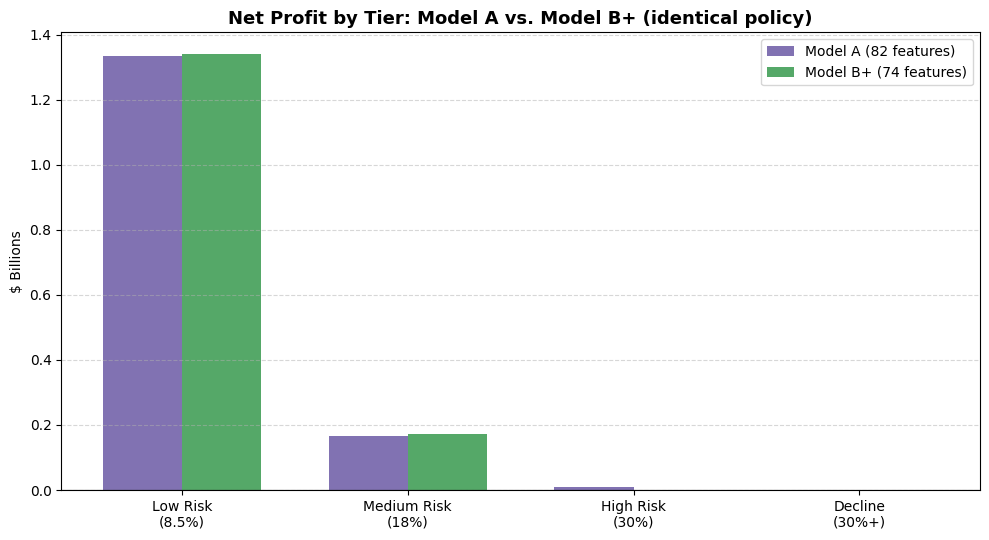

In [ ]:
tiers_plot_ab = ['Low Risk\n(8.5%)', 'Medium Risk\n(18%)', 'High Risk\n(30%)', 'Decline\n(30%+)']
net_a = profit_table_a.iloc[:4]['Net Profit'].values / 1e9
net_bp = profit_table_v3.iloc[:4]['Net Profit'].values / 1e9

x = np.arange(len(tiers_plot_ab))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(x - width/2, net_a, width, label=f'Model A ({len(final_feature_selection)} features)', color='#8172B2')
ax.bar(x + width/2, net_bp, width, label=f'Model B+ ({len(model_b_plus_features)} features)', color='#55A868')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(tiers_plot_ab)
ax.set_ylabel('$ Billions')
ax.set_title('Net Profit by Tier: Model A vs. Model B+ (identical policy)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
rate_range = np.arange(0.10, 0.35, 0.01)
medium_v2_sweep = sweep_rate_v2('Medium Risk (10-25%)', rf_bp_cal_proba, y_test, principal_test,
                                 rate_range, risk_bins_v2, risk_labels_v2)

medium_v2_breakeven = medium_v2_sweep[medium_v2_sweep['Net Profit'] > 0]['Rate'].min()
print(f"Medium Risk (10-25%) breakeven rate: {medium_v2_breakeven:.0%}")

Medium Risk (10-25%) breakeven rate: 16%


In [ ]:
# Coarse policy: decline the entire original High Risk band (25-40%)
coarse_tiers = pd.cut(rf_bp_cal_proba, bins=risk_bins, labels=risk_labels, include_lowest=True)
coarse_high_risk_count = (coarse_tiers == 'High Risk (25-40%)').sum()

# Narrow policy: only the 25-30% sub-tier is approved; 30%+ is declined
narrow_approved_count = (pd.cut(rf_bp_cal_proba, bins=risk_bins_v2, labels=risk_labels_v2,
                                  include_lowest=True) == 'High Risk (25-30%)').sum()

more_served = narrow_approved_count
print(f"Applicants in the original 25-40% band (all declined under the coarse policy): {coarse_high_risk_count}")
print(f"Applicants approved under the narrowed 25-30% sub-tier: {narrow_approved_count}")
print(f"More applicants served profitably by narrowing the tier: {more_served}")

Applicants in the original 25-40% band (all declined under the coarse policy): 2628
Applicants approved under the narrowed 25-30% sub-tier: 1437
More applicants served profitably by narrowing the tier: 1437


## 10. Customer Segmentation: Risk Personas

Unsupervised clustering is used to identify natural applicant segments beyond
the four supervised risk tiers, extending the CIND119 project's clustering
approach to this dataset. The number of clusters is chosen using the Elbow
Method and Silhouette Score, then each cluster is profiled by its mean
behavioral/demographic characteristics and actual default rate, producing
named personas a lending team could use directly — connecting back to RQ1's
question of what these patterns tell a lending team about thin-file applicants.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Build the full population (train + test) once, with a clean sequential index —
# X_train_full/X_test_full both came from separate CSVs with their own 0..N-1 index,
# so concatenating without ignore_index=True would create duplicate index labels
full_population = pd.concat([X_train_full, X_test_full], ignore_index=True)
full_target = pd.concat([y_train, y_test], ignore_index=True)

# K-Means needs scaled numeric features — use Model B+'s feature set (no protected characteristics),
# consistent with the ethically-constrained model this project recommends for production
cluster_features = [f for f in model_b_plus_features if X_test_bp[f].nunique() > 2]  # drop pure binary flags, keep continuous/ordinal signal

X_cluster_raw = full_population[cluster_features]  # full population, not just one split
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster_raw)

print(f"Clustering on {X_cluster_scaled.shape[0]:,} applicants, {X_cluster_scaled.shape[1]} scaled features")

Clustering on 307,504 applicants, 48 scaled features


### Choosing k

Before committing to a final number of clusters, the Elbow Method (inertia — how tightly packed each cluster is) and Silhouette Score (how well-separated clusters are from each other) are checked across k=2 to 8, on a 20k-row sample for speed. Both are run on the same sample so they can be compared directly.

k=2: inertia=887,101, silhouette=0.9751
k=3: inertia=832,831, silhouette=0.1393
k=4: inertia=793,291, silhouette=0.0725
k=5: inertia=743,503, silhouette=0.0795
k=6: inertia=720,136, silhouette=0.0795
k=7: inertia=697,589, silhouette=0.0824
k=8: inertia=679,855, silhouette=0.0810


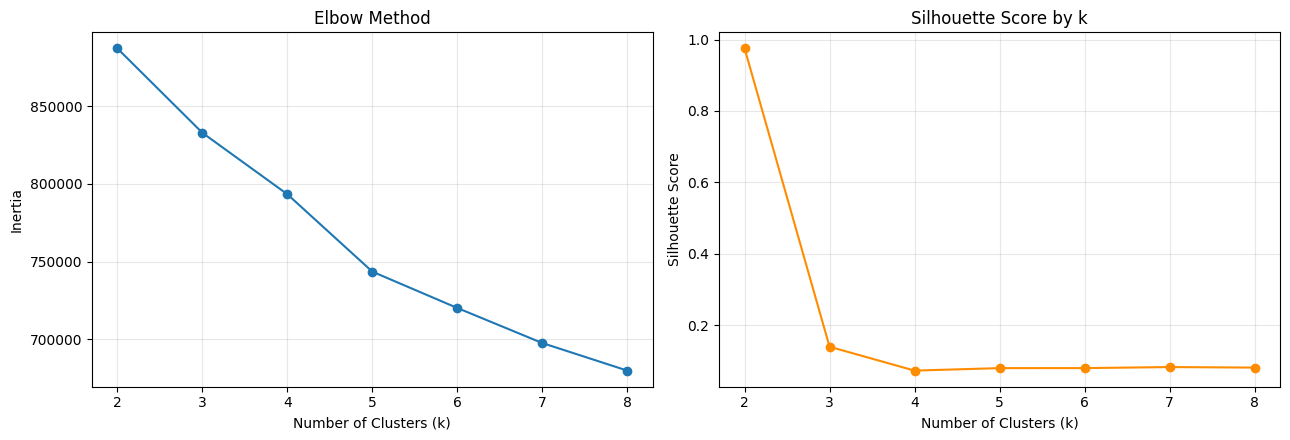

In [ ]:
# Test k from 2 to 8; use a sample for speed since full-population KMeans across many k values is slow
sample_idx = np.random.RandomState(RANDOM_STATE).choice(X_cluster_scaled.shape[0], size=20000, replace=False)
X_cluster_sample = X_cluster_scaled[sample_idx]

inertias = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster_sample)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_sample, labels))
    print(f"k={k}: inertia={km.inertia_:,.0f}, silhouette={silhouette_scores[-1]:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.plot(list(k_range), inertias, marker='o')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(alpha=0.3)

ax2.plot(list(k_range), silhouette_scores, marker='o', color='darkorange')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score by k')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
km2 = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
labels2 = km2.fit_predict(X_cluster_sample)
print(pd.Series(labels2).value_counts())

0    19999
1        1
Name: count, dtype: int64


In [ ]:
# Fit final K-Means with k=3, justified by Silhouette Score
FINAL_K = 3

kmeans_final = KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_cluster_scaled)

# Attach cluster labels back to the original (unscaled) population for interpretable profiling
df_clustered = full_population.copy()
df_clustered['TARGET'] = full_target.values
df_clustered['cluster'] = cluster_labels

print(f"Cluster sizes:\n{df_clustered['cluster'].value_counts().sort_index()}")
print(f"\nOverall dataset default rate: {df_clustered['TARGET'].mean():.4f}")
print(f"\nDefault rate by cluster:")
print(df_clustered.groupby('cluster')['TARGET'].mean().round(4))

Cluster sizes:
cluster
0     70052
1    156148
2     81304
Name: count, dtype: int64

Overall dataset default rate: 0.0807

Default rate by cluster:
cluster
0    0.0958
1    0.0864
2    0.0568
Name: TARGET, dtype: float64


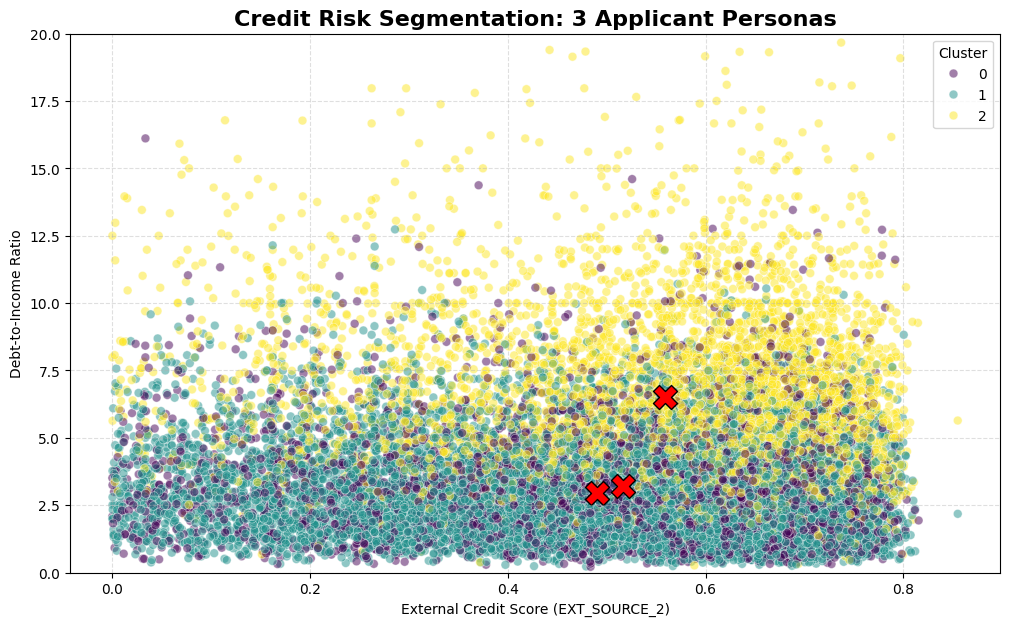

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_clustered.sample(20000, random_state=RANDOM_STATE),
                 x='EXT_SOURCE_2', y='RATIO_DEBT_TO_INCOME', hue='cluster', palette='viridis', s=40, alpha=0.5)

for i in range(FINAL_K):
    subset = df_clustered[df_clustered['cluster'] == i]
    plt.scatter(subset['EXT_SOURCE_2'].mean(), subset['RATIO_DEBT_TO_INCOME'].mean(),
                s=300, c='red', marker='X', edgecolors='black')

plt.ylim(0, 20)  # zoom out extreme debt-to-income outliers for readability
plt.title('Credit Risk Segmentation: 3 Applicant Personas', fontsize=16, fontweight='bold')
plt.xlabel('External Credit Score (EXT_SOURCE_2)')
plt.ylabel('Debt-to-Income Ratio')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

In [ ]:
occupation_cols = [c for c in df_clustered.columns if c.startswith('OCCUPATION_TYPE_')]

profile_rows = []
for cluster_id in sorted(df_clustered['cluster'].unique()):
    subset = df_clustered[df_clustered['cluster'] == cluster_id]

    # Most common occupation: whichever OCCUPATION_TYPE_* dummy column has the highest mean (share of 1s)
    top_occ_col = subset[occupation_cols].mean().idxmax()
    top_occ_share = subset[occupation_cols].mean().max()
    top_occ_name = top_occ_col.replace('OCCUPATION_TYPE_', '')

    profile_rows.append({
        'Cluster': cluster_id,
        'Size': len(subset),
        'Size (%)': f"{len(subset) / len(df_clustered):.1%}",
        'Median Age': f"{subset['AGE_YEARS'].median():.1f}",
        'Median EXT_SOURCE_2': f"{subset['EXT_SOURCE_2'].median():.3f}",
        'Median Debt-to-Income': f"{subset['RATIO_DEBT_TO_INCOME'].median():.2f}",
        'Median Credit Amount': f"${subset['AMT_CREDIT'].median():,.0f}",
        'Top Occupation': f"{top_occ_name} ({top_occ_share:.1%})",
        'Not Employed (%)': f"{subset['OCCUPATION_TYPE_Not_Employed'].mean():.1%}",
        'Actual Default Rate': f"{subset['TARGET'].mean():.2%}",
    })

cluster_profile = pd.DataFrame(profile_rows).set_index('Cluster')
print(cluster_profile.T)

Cluster                               0                 1                 2
Size                              70052            156148             81304
Size (%)                          22.8%             50.8%             26.4%
Median Age                         44.8              41.2              44.6
Median EXT_SOURCE_2               0.568             0.540             0.607
Median Debt-to-Income              2.82              2.63              6.00
Median Credit Amount           $500,211          $322,787        $1,024,740
Top Occupation         Laborers (27.3%)  Laborers (28.3%)  Laborers (24.6%)
Not Employed (%)                  18.3%             20.2%             14.1%
Actual Default Rate               9.58%             8.64%             5.68%


### Naming the personas

With `FINAL_K=3` fit on the full population, each cluster is profiled by its median demographic/behavioral values and actual default rate, and given a plain-language lending recommendation based on that default rate.

In [ ]:
for cluster_id in sorted(df_clustered['cluster'].unique()):
    subset = df_clustered[df_clustered['cluster'] == cluster_id]
    default_rate = subset['TARGET'].mean() * 100

    if default_rate < 8.0:
        strategy = "APPROVE CONFIDENTLY: Low-Risk Segment"
    elif default_rate < 9.0:
        strategy = "STANDARD REVIEW: Moderate-Risk Segment"
    else:
        strategy = "MANUAL UNDERWRITING: Higher-Risk Segment, Additional Verification Recommended"

    persona_data = {
        "Attribute": ["Recommendation", "Segment Size", "Median Age", "Median External Score (EXT_SOURCE_2)",
                      "Median Debt-to-Income", "Top Occupation", "Not Employed (%)",
                      "Median Credit Amount", "DEFAULT RATE (KPI)"],
        "Description": [
            strategy,
            f"{len(subset):,} applicants ({len(subset)/len(df_clustered)*100:.1f}% of population)",
            f"{subset['AGE_YEARS'].median():.1f} years",
            f"{subset['EXT_SOURCE_2'].median():.3f}",
            f"{subset['RATIO_DEBT_TO_INCOME'].median():.2f}",
            subset['OCCUPATION_TYPE_Laborers'].mean() > 0.5 and "Laborers" or "Mixed/Other",
            f"{subset['OCCUPATION_TYPE_Not_Employed'].mean()*100:.1f}%",
            f"${subset['AMT_CREDIT'].median():,.0f}",
            f"{default_rate:.2f}%"
        ]
    }

    print(f"\n{'='*80}\n APPLICANT PROFILE: CLUSTER {cluster_id}\n{'='*80}")
    print(pd.DataFrame(persona_data).to_string(index=False, justify='left'))


 APPLICANT PROFILE: CLUSTER 0
Attribute                            Description                                                                  
                      Recommendation MANUAL UNDERWRITING: Higher-Risk Segment, Additional Verification Recommended
                        Segment Size                                       70,052 applicants (22.8% of population)
                          Median Age                                                                    44.8 years
Median External Score (EXT_SOURCE_2)                                                                         0.568
               Median Debt-to-Income                                                                          2.82
                      Top Occupation                                                                   Mixed/Other
                    Not Employed (%)                                                                         18.3%
                Median Credit Amount             

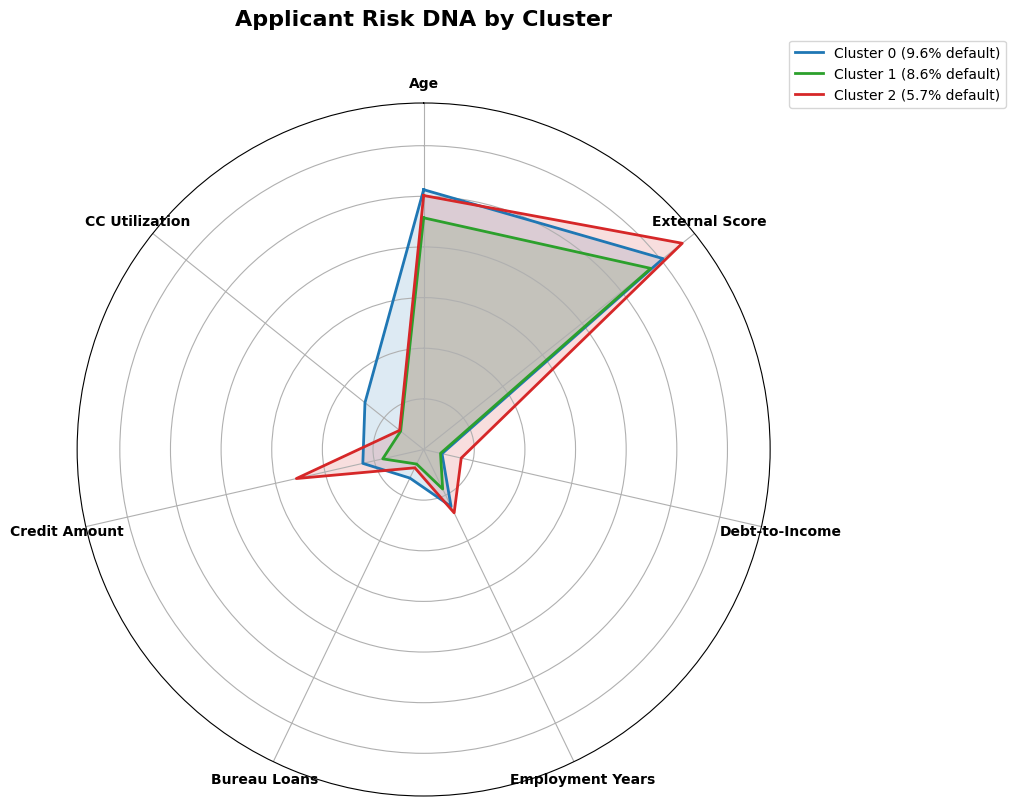

In [ ]:
from sklearn.preprocessing import MinMaxScaler

radar_features = ['AGE_YEARS', 'EXT_SOURCE_2', 'RATIO_DEBT_TO_INCOME', 'EMPLOYED_YEARS',
                   'BUR_TOTAL_LOANS', 'AMT_CREDIT', 'CC_AVG_UTILIZATION']
radar_labels = ['Age', 'External Score', 'Debt-to-Income', 'Employment Years',
                'Bureau Loans', 'Credit Amount', 'CC Utilization']

scaler_mm = MinMaxScaler()
df_rescaled = pd.DataFrame(scaler_mm.fit_transform(df_clustered[radar_features].fillna(0)), columns=radar_features)
df_rescaled['cluster'] = df_clustered['cluster'].values
cluster_summary = df_rescaled.groupby('cluster').mean().reset_index()

num_vars = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

colors = ['#1f77b4', '#2ca02c', '#d62728']
names = [f'Cluster {i} ({df_clustered[df_clustered["cluster"]==i]["TARGET"].mean()*100:.1f}% default)' for i in range(FINAL_K)]

for i in range(FINAL_K):
    values = cluster_summary.iloc[i][radar_features].values.tolist()
    values += values[:1]
    ax.plot(angles, values, color=colors[i], linewidth=2, label=names[i])
    ax.fill(angles, values, color=colors[i], alpha=0.15)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10, fontweight='bold')
ax.set_yticklabels([])

plt.title('Applicant Risk DNA by Cluster', size=16, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.show()

In [ ]:
occupation_cols = [c for c in df_clustered.columns if c.startswith('OCCUPATION_TYPE_')]

for cluster_id in sorted(df_clustered['cluster'].unique()):
    subset = df_clustered[df_clustered['cluster'] == cluster_id]
    top_occupation = subset[occupation_cols].mean().idxmax().replace('OCCUPATION_TYPE_', '')
    top_occupation_pct = subset[occupation_cols].mean().max() * 100
    print(f"Cluster {cluster_id}: {top_occupation} ({top_occupation_pct:.1f}% of cluster)")

Cluster 0: Laborers (27.3% of cluster)
Cluster 1: Laborers (28.3% of cluster)
Cluster 2: Laborers (24.6% of cluster)


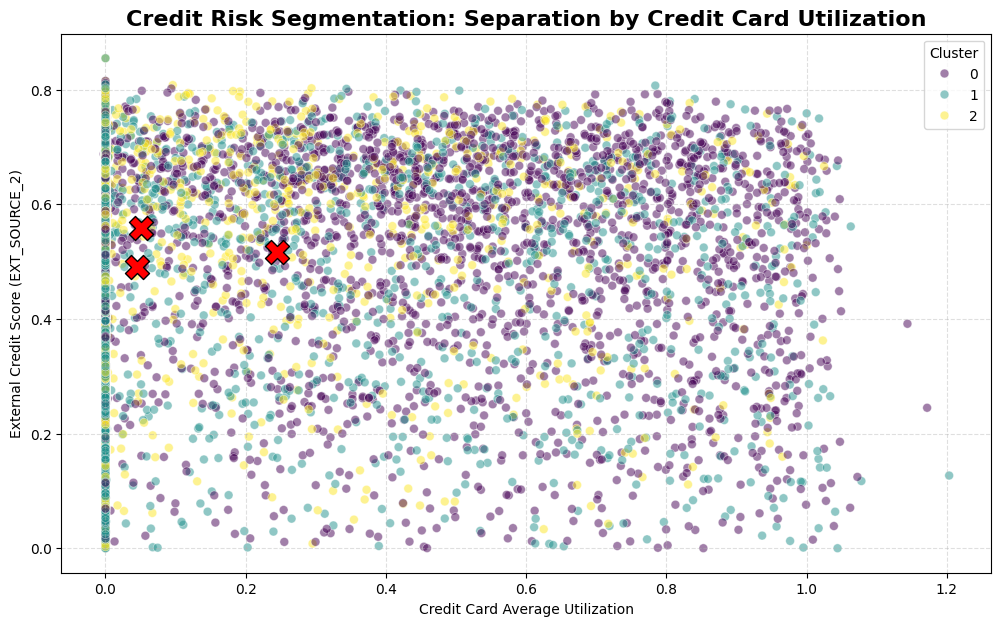

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_clustered.sample(20000, random_state=RANDOM_STATE),
                 x='CC_AVG_UTILIZATION', y='EXT_SOURCE_2', hue='cluster', palette='viridis', s=40, alpha=0.5)

for i in range(FINAL_K):
    subset = df_clustered[df_clustered['cluster'] == i]
    plt.scatter(subset['CC_AVG_UTILIZATION'].mean(), subset['EXT_SOURCE_2'].mean(),
                s=300, c='red', marker='X', edgecolors='black')

plt.title('Credit Risk Segmentation: Separation by Credit Card Utilization', fontsize=16, fontweight='bold')
plt.xlabel('Credit Card Average Utilization')
plt.ylabel('External Credit Score (EXT_SOURCE_2)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

In [ ]:
df_clustered.groupby('cluster')['CC_AVG_UTILIZATION'].median()

,CC_AVG_UTILIZATION
cluster,
0,0.0
1,0.0
2,0.0


In [ ]:
df_clustered.groupby('cluster')['CC_AVG_UTILIZATION'].agg(['mean', lambda x: (x > 0).mean()])

,mean,<lambda_0>
cluster,,
0,0.244762,0.468167
1,0.044277,0.099982
2,0.050088,0.135578


Rather than revealing distinct, sharply-separated risk archetypes, K-Means identified a continuum. "Laborers" is the single most common occupation in all three clusters (24.6%-28.3%), reflecting its dominance across the population as a whole rather than any cluster-specific pattern. Cluster 2 (26.4% of applicants) combines the largest median credit amount ($1,024,740), the strongest external credit score (0.607), and the lowest default rate (5.68%) — its elevated debt-to-income ratio (6.00) reflects large loans extended against strong underlying creditworthiness, not financial strain. Clusters 0 and 1 are closer on most dimensions, but differ meaningfully in credit card usage: 46.8% of Cluster 0 carries a nonzero card balance, compared to just 10.0% of Cluster 1, consistent with Cluster 0's higher default rate (9.58% vs. 8.64%). Combined with the weak overall silhouette score (0.1393), this suggests a population with one clearly separable low-risk segment (Cluster 2) and two more closely related, moderate-risk segments distinguished primarily by active credit card usage rather than by demographic or occupational differences.

In [ ]:
import warnings
warnings.filterwarnings('ignore') # to ignore fairlearn warnings

!pip install fairlearn --quiet
from fairlearn.metrics import (MetricFrame, demographic_parity_difference,
                                equalized_odds_difference, selection_rate)

# Use CODE_GENDER from the original dataframe as the sensitive feature —
# it's not a model input for Model B+, but we still have it to audit against
sensitive_feature = X_test_full.loc[X_test_bp.index, 'CODE_GENDER']

dp_diff = demographic_parity_difference(y_test, rf_bp_cal_preds, sensitive_features=sensitive_feature)
eo_diff = equalized_odds_difference(y_test, rf_bp_cal_preds, sensitive_features=sensitive_feature)

selection_rates = MetricFrame(metrics=selection_rate, y_true=y_test, y_pred=rf_bp_cal_preds,
                               sensitive_features=sensitive_feature)
disparate_impact_ratio = selection_rates.by_group.min() / selection_rates.by_group.max()

print("=== FAIRLEARN AUDIT: Model B+ predictions by CODE_GENDER ===")
print(f"Demographic Parity Difference: {dp_diff:.4f}  (0 = perfect parity)")
print(f"Equalized Odds Difference: {eo_diff:.4f}  (0 = perfect parity)")
print(f"Disparate Impact Ratio: {disparate_impact_ratio:.4f}  (>0.80 is generally considered acceptable — the '80% rule')")
print(f"\nSelection rate (approval rate) by gender:")
print(selection_rates.by_group)

=== FAIRLEARN AUDIT: Model B+ predictions by CODE_GENDER ===
Demographic Parity Difference: 0.0000  (0 = perfect parity)
Equalized Odds Difference: 0.0000  (0 = perfect parity)
Disparate Impact Ratio: 0.0000  (>0.80 is generally considered acceptable — the '80% rule')

Selection rate (approval rate) by gender:
CODE_GENDER
0.0    0.000000
1.0    0.000025
Name: selection_rate, dtype: float64


The initial selection-rate comparison is not meaningful on its own: both selection rates are effectively 0% (0.0000 and 0.000025), since rf_bp_cal_preds — the raw .predict() output at scikit-learn's default 0.5 threshold — classifies almost no applicant as a defaulter. The calibrated probability range established earlier (0.0065 to 0.5025) confirms why: almost no applicant crosses the 0.5 threshold after calibration. Comparing two near-zero numbers produces a ratio that appears extreme but is a divide-by-near-zero artifact rather than evidence of bias.
The corrected approach defines "selection" as loan approval under the actual tier policy — landing in Low, Medium, or High Risk versus Decline — rather than the default 0.5 classification threshold, which was never a meaningful cutoff for this imbalanced problem. This is consistent with the project's use of F2/recall rather than accuracy as the primary evaluation metric throughout.

In [ ]:
# Redefine "selection" as loan approval under the actual final tier policy,
# not the raw 0.5-threshold classifier output (which is degenerate here —
# almost no one crosses 0.5 after calibration, making the previous result meaningless)

approved = (pd.cut(rf_bp_cal_proba, bins=risk_bins_v2, labels=risk_labels_v2, include_lowest=True) != 'Decline (30%+)').astype(int)

sensitive_feature = X_test_full.loc[X_test_bp.index, 'CODE_GENDER']

dp_diff = demographic_parity_difference(y_test, approved, sensitive_features=sensitive_feature)
eo_diff = equalized_odds_difference(y_test, approved, sensitive_features=sensitive_feature)

approval_rates = MetricFrame(metrics=selection_rate, y_true=y_test, y_pred=approved,
                               sensitive_features=sensitive_feature)
disparate_impact_ratio = approval_rates.by_group.min() / approval_rates.by_group.max()

print("=== FAIRLEARN AUDIT: Loan Approval Rate by CODE_GENDER ===")
print(f"Demographic Parity Difference: {dp_diff:.4f}  (0 = perfect parity)")
print(f"Equalized Odds Difference: {eo_diff:.4f}  (0 = perfect parity)")
print(f"Disparate Impact Ratio: {disparate_impact_ratio:.4f}  (>0.80 is generally considered acceptable — the '80% rule')")
print(f"\nApproval rate by gender:")
print(approval_rates.by_group)

=== FAIRLEARN AUDIT: Loan Approval Rate by CODE_GENDER ===
Demographic Parity Difference: 0.0099  (0 = perfect parity)
Equalized Odds Difference: 0.0134  (0 = perfect parity)
Disparate Impact Ratio: 0.9899  (>0.80 is generally considered acceptable — the '80% rule')

Approval rate by gender:
CODE_GENDER
0.0    0.971584
1.0    0.981509
Name: selection_rate, dtype: float64


The Disparate Impact Ratio of 0.9899 comfortably clears the 0.80 "80% rule" threshold used by regulators, with a wide margin: approval rates are 97.2% for one gender and 98.2% for the other, a gap of roughly one percentage point. The Demographic Parity Difference (0.0099) and Equalized Odds Difference (0.0134) are both close to the ideal of 0, indicating that approval rates and error rates are nearly similar across gender groups.
This result, measured against the correct policy-based selection definition, confirms what the SHAP analysis already suggested: Model B+ produces near-equal outcomes across gender despite gender never being a model input. The proxy features that were absorbing removed protected-characteristic signal — OCCUPATION_TYPE_Laborers, FLAG_MISSING_DAYS_EMPLOYED, and ORGANIZATION_TYPE_XNA, identified via a statistical threshold rather than a single hand-picked feature — were removed in Model B+, and a second round of the same rank-jump check found no further proxies: four features that moved up afterward showed no meaningful correlation (all under |0.07|) with any of the six original protected characteristics, confirming they reflected ordinary importance redistribution rather than a second wave of proxy leakage. Together, these analyses — SHAP identifying and removing the proxy features, a correlation check confirming no further leakage remained, the paired t-test finding no significant difference on Recall or AUC-ROC between Model A and Model B, and the Fairlearn audit confirming the regulatory fairness metric passes with wide margin — form a complete evidence chain answering RQ3's fairness question.

In [ ]:
# Setup Helpers
occupation_cols = [c for c in X_test_full.columns if c.startswith('OCCUPATION_TYPE_')]

tier_rate_map = {
    'Low Risk (0-10%)': 0.085,
    'Medium Risk (10-25%)': 0.18,
    'High Risk (25-30%)': 0.30,
    'Decline (30%+)': None
}

# Build the tier assignment using Model B+'s calibrated probabilities and the final policy bins
test_tiers = pd.cut(rf_bp_cal_proba, bins=risk_bins_v2, labels=risk_labels_v2, include_lowest=True)
df_tiers = X_test_full.loc[X_test_bp.index].copy()
df_tiers['risk_tier'] = test_tiers  # pd.cut on a plain array returns a Categorical, which
                                     # already assigns directly — no .values needed
df_tiers['actual_default'] = y_test.values

for tier_name in risk_labels_v2:
    subset = df_tiers[df_tiers['risk_tier'] == tier_name]

    default_rate = subset['actual_default'].mean() * 100
    assigned_rate = tier_rate_map[tier_name]
    top_occupation = subset[occupation_cols].mean().idxmax().replace('OCCUPATION_TYPE_', '')
    top_occupation_pct = subset[occupation_cols].mean().max() * 100
    not_employed_pct = subset['OCCUPATION_TYPE_Not_Employed'].mean() * 100

    # Strategy logic based on this project's final lending policy
    if assigned_rate is None:
        strategy = "❌ DECLINE: Unprofitable at Any Legal Rate (>35% APR Cap)"
    elif tier_name == 'Low Risk (0-10%)':
        strategy = "⭐ APPROVE: Prime Rate, Lowest Risk Segment"
    elif tier_name == 'Medium Risk (10-25%)':
        strategy = "✅ APPROVE: Standard Rate, Profitable Segment"
    else:
        strategy = "⚠️ APPROVE WITH CAUTION: Elevated Rate, Marginally Profitable"

    persona_data = {
        "Attribute": ["Final Recommendation", "Segment Size", "Median Age",
                      "Median External Score (EXT_SOURCE_2)", "Median Debt-to-Income",
                      "Top Occupation", "Not Employed (%)", "Median Credit Amount",
                      "Assigned APR", "ACTUAL DEFAULT RATE (KPI)"],
        "Description": [
            strategy,
            f"{len(subset):,} applicants ({len(subset)/len(df_tiers)*100:.1f}% of test set)",
            f"{subset['AGE_YEARS'].median():.1f} years",
            f"{subset['EXT_SOURCE_2'].median():.3f}",
            f"{subset['RATIO_DEBT_TO_INCOME'].median():.2f}",
            f"{top_occupation} ({top_occupation_pct:.1f}%)",
            f"{not_employed_pct:.1f}%",
            f"${subset['AMT_CREDIT'].median():,.0f}",
            f"{assigned_rate:.1%}" if assigned_rate is not None else "N/A — Not Approved",
            f"{default_rate:.2f}%"
        ]
    }

    print(f"\n{'='*80}\n RISK TIER PROFILE: {tier_name.upper()}\n{'='*80}")
    print(pd.DataFrame(persona_data).to_string(index=False, justify='left'))


 RISK TIER PROFILE: LOW RISK (0-10%)
Attribute                            Description                               
                Final Recommendation ⭐ APPROVE: Prime Rate, Lowest Risk Segment
                        Segment Size      44,953 applicants (73.1% of test set)
                          Median Age                                 45.8 years
Median External Score (EXT_SOURCE_2)                                      0.607
               Median Debt-to-Income                                       3.33
                      Top Occupation                           Laborers (23.6%)
                    Not Employed (%)                                      23.1%
                Median Credit Amount                                   $536,918
                        Assigned APR                                       8.5%
           ACTUAL DEFAULT RATE (KPI)                                      4.30%

 RISK TIER PROFILE: MEDIUM RISK (10-25%)
Attribute                            Des

In [ ]:
import joblib

full_checkpoint = {
    # --- Section 6: Model A / Model B ---
    'protected_features': protected_features,
    'model_b_features': model_b_features,
    'rf_b_preds': rf_b_preds,
    'rf_b_proba': rf_b_proba,
    'rf_a_preds': rf_a_preds,
    'rf_a_proba': rf_a_proba,
    'rf_b_summary': rf_b_summary,
    'rf_b_fold_scores': rf_b_fold_scores,

    # --- Section 7: SHAP ---
    'shap_values_b_positive': shap_values_b_positive,
    'mean_abs_shap_b': mean_abs_shap_b,
    'shap_values_a_positive': shap_values_a_positive,
    'mean_abs_shap_a': mean_abs_shap_a,
    'proxy_check': proxy_check,
    'model_b_plus_features': model_b_plus_features,
    'rf_bp_preds': rf_bp_preds,
    'rf_bp_proba': rf_bp_proba,
    'shap_values_bp_positive': shap_values_bp_positive,
    'mean_abs_shap_bp': mean_abs_shap_bp,
    'proxy_check_bp': proxy_check_bp,

    # --- Section 8: Calibration ---
    'rf_bp_cal_preds': rf_bp_cal_preds,
    'rf_bp_cal_proba': rf_bp_cal_proba,
    'raw_tiers': raw_tiers,
    'calibrated_tiers': calibrated_tiers,
    'rf_a_cal_proba': rf_a_cal_proba,

    # --- Section 9: Business value ---
    'principal_test': principal_test,
    'risk_bins_v2': risk_bins_v2,
    'risk_labels_v2': risk_labels_v2,
    'tier_rates_v3': tier_rates_v3,
    'profit_table_v3': profit_table_v3,
    'profit_table_a': profit_table_a,
    'high_v2_breakeven': high_v2_breakeven,

    # --- Section 10: Clustering ---
    'cluster_features': cluster_features,
    'FINAL_K': FINAL_K,
    'df_clustered': df_clustered,

    # --- Section 11: Fairness audit ---
    'dp_diff': dp_diff,
    'eo_diff': eo_diff,
    'disparate_impact_ratio': disparate_impact_ratio,
    'approval_rates_by_group': approval_rates.by_group,
}

joblib.dump(full_checkpoint, '/content/drive/MyDrive/CIND820_Project/milestone4_full_run_checkpoint.pkl')

# Fitted models are saved separately since large sklearn/CalibratedClassifierCV objects
# pickle more reliably on their own than nested inside a dict of mixed types
joblib.dump(rf_model_b, '/content/drive/MyDrive/CIND820_Project/rf_model_b.pkl')
joblib.dump(rf_model_a, '/content/drive/MyDrive/CIND820_Project/rf_model_a.pkl')
joblib.dump(rf_model_bp, '/content/drive/MyDrive/CIND820_Project/rf_model_bp.pkl')
joblib.dump(rf_bp_calibrated, '/content/drive/MyDrive/CIND820_Project/rf_bp_calibrated.pkl')
joblib.dump(rf_a_calibrated, '/content/drive/MyDrive/CIND820_Project/rf_a_calibrated.pkl')
joblib.dump(kmeans_final, '/content/drive/MyDrive/CIND820_Project/kmeans_final.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/CIND820_Project/cluster_scaler.pkl')

print("Full checkpoint saved — Sections 6 through 11 can now be reloaded without re-running.")

NameError: name 'rf_b_summary' is not defined

## 12. Bonus Work: Model B Profitability (Full Three-Way Comparison)

Sections 6–9 established Model A and Model B+ profitability but never ran
Model B (protected features removed, proxies still present) through the same
calibration + interest-rate pipeline. This section closes that gap so the
A → B → B+ progression can be reported in dollars end to end, not just
accuracy/AUC-ROC for the A→B step and dollars for the B→B+ step.

Self-contained: reloads the saved Model B object and checkpoint rather than
depending on Sections 6–9 having been re-run in this session.

In [ ]:
# --- Load what Section 12 needs, independent of what else ran this session ---
import joblib
from sklearn.calibration import CalibratedClassifierCV

full_checkpoint = joblib.load('/content/drive/MyDrive/CIND820_Project/milestone4_full_run_checkpoint.pkl')
rf_model_b = joblib.load('/content/drive/MyDrive/CIND820_Project/rf_model_b.pkl')

model_b_features = full_checkpoint['model_b_features']
principal_test   = full_checkpoint['principal_test']
risk_bins_v2     = full_checkpoint['risk_bins_v2']
risk_labels_v2   = full_checkpoint['risk_labels_v2']
tier_rates_v3    = full_checkpoint['tier_rates_v3']
profit_table_a   = full_checkpoint['profit_table_a']
profit_table_v3  = full_checkpoint['profit_table_v3']  # Model B+

# Requires X_train, X_test, y_train, y_test already loaded (Section 2: leakage-safe split)
X_train_b = X_train[model_b_features]
X_test_b  = X_test[model_b_features]

print("Section 12 setup complete — Model B reloaded, checkpoint values restored.")

Section 12 setup complete — Model B reloaded, checkpoint values restored.


In [ ]:
# --- Calibrate Model B the same way as A and B+ (sigmoid/Platt, cv=5) ---
rf_b_calibrated = CalibratedClassifierCV(rf_model_b, method='sigmoid', cv=5)
rf_b_calibrated.fit(X_train_b, y_train)
rf_b_cal_proba = rf_b_calibrated.predict_proba(X_test_b)[:, 1]

print("Model B calibrated.")
print(f"Calibrated probability range: {rf_b_cal_proba.min():.4f} to {rf_b_cal_proba.max():.4f}")

Model B calibrated.
Calibrated probability range: 0.0065 to 0.4811


In [ ]:
# --- Redefine calculate_profit locally so this section doesn't depend on Section 9 ---
RECOVERY_RATE = 0.20

def calculate_profit(proba, y_true, principal, rates_dict, bins, labels):
    tiers = pd.cut(proba, bins=bins, labels=labels, include_lowest=True)
    results = pd.DataFrame({'tier': tiers, 'actual_default': y_true.values, 'principal': principal.values})
    profit_rows = []
    for tier in labels:
        subset = results[results['tier'] == tier]
        rate = rates_dict[tier]
        if rate is None:
            profit_rows.append({'Tier': tier, 'Applicants': len(subset), 'Rate': 'N/A',
                                 'Revenue': 0, 'Losses': 0, 'Net Profit': 0})
            continue
        repaid = subset[subset['actual_default'] == 0]
        defaulted = subset[subset['actual_default'] == 1]
        revenue = (repaid['principal'] * rate).sum()
        losses = (defaulted['principal'] * (1 - RECOVERY_RATE)).sum()
        profit_rows.append({'Tier': tier, 'Applicants': len(subset), 'Rate': f'{rate:.1%}',
                             'Revenue': revenue, 'Losses': losses, 'Net Profit': revenue - losses})
    return pd.DataFrame(profit_rows)

profit_table_b = calculate_profit(rf_b_cal_proba, y_test, principal_test, tier_rates_v3,
                                   bins=risk_bins_v2, labels=risk_labels_v2)
profit_table_b.loc['TOTAL'] = ['—', profit_table_b['Applicants'].sum(), '—',
                                profit_table_b['Revenue'].sum(), profit_table_b['Losses'].sum(),
                                profit_table_b['Net Profit'].sum()]

print("=== MODEL B (protected removed, no proxy audit) — PROFIT BY TIER ===")
print(profit_table_b.to_string(index=False))

a  = profit_table_a.loc['TOTAL', 'Net Profit']
b  = profit_table_b.loc['TOTAL', 'Net Profit']
bp = profit_table_v3.loc['TOTAL', 'Net Profit']

print(f"\n=== THREE-WAY PROFIT COMPARISON (same policy, same test set) ===")
print(f"Model A  (82 features, unconstrained):        ${a:,.2f}")
print(f"Model B  (77 features, protected removed):     ${b:,.2f}")
print(f"Model B+ (74 features, proxies also removed):  ${bp:,.2f}")
print(f"\nA -> B:  ${b - a:,.2f}")
print(f"B -> B+: ${bp - b:,.2f}")
print(f"A -> B+: ${bp - a:,.2f}")

=== MODEL B (protected removed, no proxy audit) — PROFIT BY TIER ===
                Tier  Applicants  Rate      Revenue       Losses   Net Profit
    Low Risk (0-10%)       44846  8.5% 2.303308e+09  980542623.6 1.322765e+09
Medium Risk (10-25%)       13931 18.0% 1.095366e+09  910214524.8 1.851514e+08
  High Risk (25-30%)        1451 30.0% 1.436173e+08  141647515.2 1.969813e+06
      Decline (30%+)        1272   N/A 0.000000e+00          0.0 0.000000e+00
                   —       61500     — 3.542291e+09 2032404663.6 1.509886e+09

=== THREE-WAY PROFIT COMPARISON (same policy, same test set) ===
Model A  (82 features, unconstrained):        $1,509,301,215.09
Model B  (77 features, protected removed):     $1,509,886,246.86
Model B+ (74 features, proxies also removed):  $1,513,349,537.92

A -> B:  $585,031.77
B -> B+: $3,463,291.06
A -> B+: $4,048,322.83


In [ ]:
# --- Compare actual default rates within each risk tier, across A / B / B+ ---
# This is the real check: did B/B+ start approving riskier applicants into
# cheaper tiers (which would inflate profit without genuinely finding fewer
# defaulters), or did the tiers stay equally "honest" about actual risk?

def build_tier_table_v2(proba, y_true, bins, labels):
    tiers = pd.cut(proba, bins=bins, labels=labels, include_lowest=True)
    table = pd.crosstab(tiers, y_true.values, rownames=['Risk Tier'], colnames=['Actual Outcome'])
    table.columns = ['Repaid (0)', 'Defaulted (1)']
    table = table.reindex(labels, fill_value=0)
    table['Total Applicants'] = table.sum(axis=1)
    table['Actual Default Rate'] = (table['Defaulted (1)'] / table['Total Applicants']).round(4)
    return table

rf_a_cal_proba  = full_checkpoint['rf_a_cal_proba']
rf_bp_cal_proba = full_checkpoint['rf_bp_cal_proba']

tiers_a  = build_tier_table_v2(rf_a_cal_proba,  y_test, risk_bins_v2, risk_labels_v2)
tiers_b  = build_tier_table_v2(rf_b_cal_proba,  y_test, risk_bins_v2, risk_labels_v2)
tiers_bp = build_tier_table_v2(rf_bp_cal_proba, y_test, risk_bins_v2, risk_labels_v2)

print("=== ACTUAL DEFAULT RATE BY TIER — MODEL A ===")
print(tiers_a[['Total Applicants', 'Actual Default Rate']])
print("\n=== ACTUAL DEFAULT RATE BY TIER — MODEL B ===")
print(tiers_b[['Total Applicants', 'Actual Default Rate']])
print("\n=== ACTUAL DEFAULT RATE BY TIER — MODEL B+ ===")
print(tiers_bp[['Total Applicants', 'Actual Default Rate']])

=== ACTUAL DEFAULT RATE BY TIER — MODEL A ===
                      Total Applicants  Actual Default Rate
Risk Tier                                                  
Low Risk (0-10%)                 44878               0.0431
Medium Risk (10-25%)             13850               0.1523
High Risk (25-30%)                1489               0.2612
Decline (30%+)                    1283               0.4139

=== ACTUAL DEFAULT RATE BY TIER — MODEL B ===
                      Total Applicants  Actual Default Rate
Risk Tier                                                  
Low Risk (0-10%)                 44846               0.0434
Medium Risk (10-25%)             13931               0.1512
High Risk (25-30%)                1451               0.2653
Decline (30%+)                    1272               0.4135

=== ACTUAL DEFAULT RATE BY TIER — MODEL B+ ===
                      Total Applicants  Actual Default Rate
Risk Tier                                                  
Low Risk (0-10%)   

In [ ]:
model_b_plus_features = full_checkpoint['model_b_plus_features']

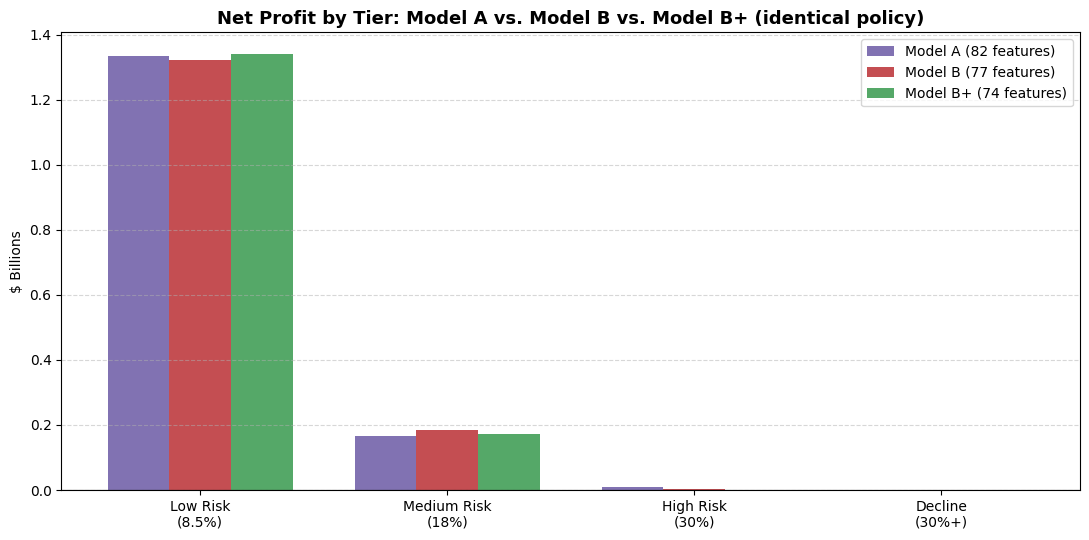

In [ ]:
# --- Three-way profit comparison chart: Model A vs. B vs. B+, by tier ---
tiers_plot_abc = ['Low Risk\n(8.5%)', 'Medium Risk\n(18%)', 'High Risk\n(30%)', 'Decline\n(30%+)']
net_a  = profit_table_a.iloc[:4]['Net Profit'].values / 1e9
net_b  = profit_table_b.iloc[:4]['Net Profit'].values / 1e9
net_bp = profit_table_v3.iloc[:4]['Net Profit'].values / 1e9

x = np.arange(len(tiers_plot_abc))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(x - width, net_a,  width, label=f'Model A ({len(final_feature_selection)} features)', color='#8172B2')
ax.bar(x,          net_b,  width, label=f'Model B ({len(model_b_features)} features)', color='#C44E52')
ax.bar(x + width,  net_bp, width, label=f'Model B+ ({len(model_b_plus_features)} features)', color='#55A868')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(tiers_plot_abc)
ax.set_ylabel('$ Billions')
ax.set_title('Net Profit by Tier: Model A vs. Model B vs. Model B+ (identical policy)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
print(f"=== SHAP breakdown for applicant index {example_id} (actual outcome: Defaulted) ===\n")
print("Applicant's actual feature values (top 10 by |SHAP| for this applicant):\n")

contributions = pd.Series(shap_values_example[0], index=model_b_plus_features)
top_10 = contributions.abs().sort_values(ascending=False).head(10).index

for feat in top_10:
    feat_value = example_row[feat].iloc[0]
    contribution = contributions[feat]
    if contribution > 0:
        direction = "higher risk"
    else:
        direction = "lower risk"
    line = f"  {feat:35s} value={feat_value:>10.3f}   pushes toward {direction}  (SHAP={contribution:+.4f})"
    print(line)

print("")
base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = base_val[1]
print(f"Base rate (average predicted risk before features considered): {base_val:.4f}")

final_prob = rf_model_bp.predict_proba(example_row)[0][1]
print(f"This applicant's final predicted probability: {final_prob:.4f}")

=== SHAP breakdown for applicant index 9 (actual outcome: Defaulted) ===

Applicant's actual feature values (top 10 by |SHAP| for this applicant):

  EXT_SOURCE_2                        value=     0.612   pushes toward lower risk  (SHAP=-0.0440)
  EXT_SOURCE_3                        value=     0.339   pushes toward higher risk  (SHAP=+0.0331)
  BUR_AVG_UTILIZATION                 value=     0.157   pushes toward lower risk  (SHAP=-0.0283)
  RATIO_CREDIT_TO_GOODS               value=     1.000   pushes toward lower risk  (SHAP=-0.0153)
  PREV_COUNT_REFUSED                  value=     2.000   pushes toward higher risk  (SHAP=+0.0152)
  NAME_INCOME_TYPE_Pensioner          value=     1.000   pushes toward lower risk  (SHAP=-0.0148)
  BUR_ACTIVE_LOANS                    value=     6.000   pushes toward higher risk  (SHAP=+0.0142)
  OCCUPATION_TYPE_Not_Employed        value=     1.000   pushes toward lower risk  (SHAP=-0.0135)
  INST_RATIO_LATE                     value=     0.000   pushes t